# 讀取切分好訓練與測試集的資料

In [1]:
import pandas as pd
# 讀取 Excel 各分頁
file_path = "doc_OS_train_test_split.xlsx"

df_train_ori = pd.read_excel(file_path, sheet_name="Train_Original")
df_test_ori = pd.read_excel(file_path, sheet_name="Test_Original")

# 定義特徵與目標變數（Training Set）
X_train = df_train_ori.drop(columns=["OS", "OS_year"])
y_OS_event_train = df_train_ori["OS"]
y_OS_time_train = df_train_ori["OS_year"]

# 定義特徵與目標變數（Testing Set）
X_test = df_test_ori.drop(columns=["OS", "OS_year"])
y_OS_event_test = df_test_ori["OS"]
y_OS_time_test = df_test_ori["OS_year"]

In [2]:
df_train_ori

,Age,ECOG,SMI_1,Stage_2,Cell_2,Grade,Resec_status,Ascites_1,BMI_1,Alb_11,NLR_1,PLR_1,OS,OS_year
0,46,0,45.572321,1,0,3,0,1,22.100290,42.0,2.333333,123.638344,0,7.326027
1,71,0,35.456448,1,0,3,0,1,17.941817,22.0,5.428571,583.138173,1,3.282192
2,55,1,46.912701,1,1,2,1,1,24.919900,35.0,4.055556,255.319149,1,0.846575
3,32,0,35.131840,0,1,2,0,0,17.718336,42.0,2.407407,101.257221,0,3.928767
4,55,0,41.820221,1,0,3,1,0,26.438071,33.0,1.358974,121.499014,1,3.632877
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
496,72,1,44.691022,1,0,3,1,1,19.735976,44.0,6.250000,555.952381,1,1.084932
497,62,0,44.727715,0,1,3,0,0,24.863745,44.0,5.133333,257.861635,0,7.104110
498,47,0,39.559786,1,0,3,0,0,17.102915,42.0,2.520000,187.796610,0,8.641096
499,64,0,45.159435,1,0,2,1,1,23.833005,45.0,4.866667,274.885845,1,3.276712


In [3]:
# 訓練集事件統計
train_OS_event_counts = y_OS_event_train.value_counts()
print("訓練集 OS 事件分布：")
print(train_OS_event_counts)
print(f"事件比例: {train_OS_event_counts[1] / train_OS_event_counts.sum():.2%} 發生, {train_OS_event_counts[0] / train_OS_event_counts.sum():.2%} 未發生\n")

# 測試集事件統計
test_OS_event_counts = y_OS_event_test.value_counts()
print("測試集 OS 事件分布：")
print(test_OS_event_counts)
print(f"事件比例: {test_OS_event_counts[1] / test_OS_event_counts.sum():.2%} 發生, {test_OS_event_counts[0] / test_OS_event_counts.sum():.2%} 未發生")

訓練集 OS 事件分布：
OS
0    323
1    178
Name: count, dtype: int64
事件比例: 35.53% 發生, 64.47% 未發生

測試集 OS 事件分布：
OS
0    81
1    45
Name: count, dtype: int64
事件比例: 35.71% 發生, 64.29% 未發生


# Spearman相關係數分析

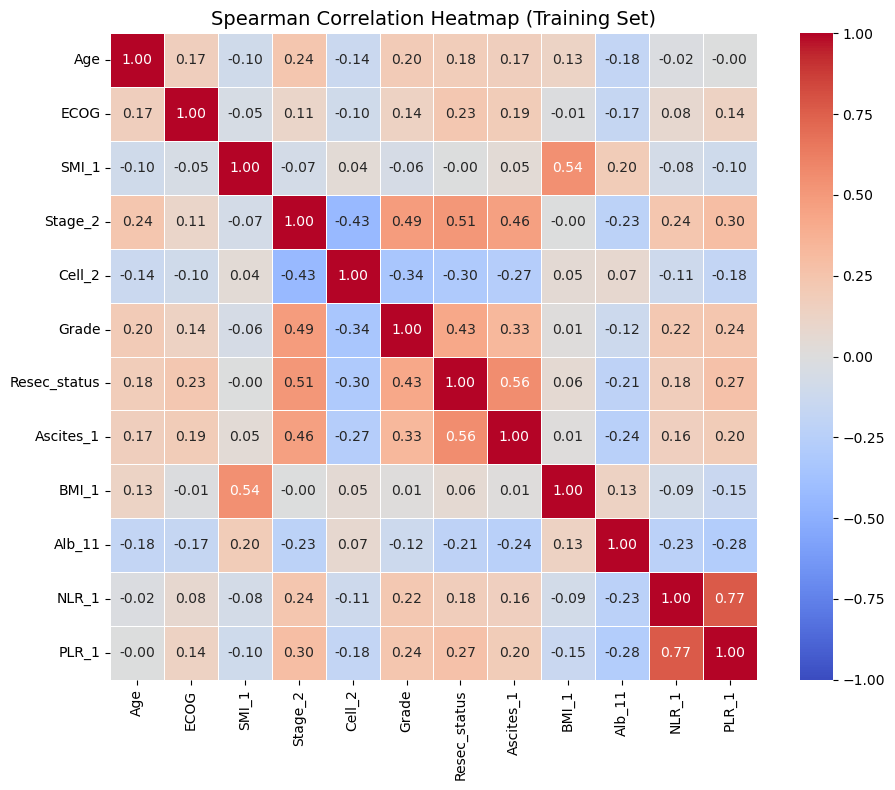


[檢查結果] 絕對值大於等於 0.7 的高度相關特徵對：
- PLR_1 與 NLR_1 (rho = 0.77)


In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 計算 Spearman 相關係數矩陣 (僅限訓練集)
spearman_corr = X_train.corr(method='spearman')

# 繪圖尺寸
plt.figure(figsize=(10, 8))


# 繪製熱圖
sns.heatmap(spearman_corr, 
            annot=True,          # 在格子內顯示相關係數數值
            fmt=".2f",           # 數值取到小數點後兩位
            cmap="coolwarm",     # 顏色配置：紅色代表正相關，藍色代表負相關
            vmin=-1, vmax=1,     # 固定顏色範圍 -1 到 1
            square=True,         
            linewidths=.5)      

plt.title("Spearman Correlation Heatmap (Training Set)", fontsize=14)
plt.tight_layout()
plt.show()

# 篩選出高度相關的特徵對 (閾值 0.7)
threshold = 0.7
print(f"\n[檢查結果] 絕對值大於等於 {threshold} 的高度相關特徵對：")

high_corr_found = False
for i in range(len(spearman_corr.columns)):
    for j in range(i): # 只檢查下半三角
        corr_value = spearman_corr.iloc[i, j]
        if abs(corr_value) >= threshold:
            colname_1 = spearman_corr.columns[i]
            colname_2 = spearman_corr.columns[j]
            print(f"- {colname_1} 與 {colname_2} (rho = {corr_value:.2f})")
            high_corr_found = True

if not high_corr_found:
    print("- 無高度相關特徵對，所有特徵皆可保留。")

# 建立生存標籤格式

In [5]:
from sksurv.util import Surv
from sksurv.linear_model import CoxPHSurvivalAnalysis
from sksurv.metrics import concordance_index_censored, cumulative_dynamic_auc, brier_score

import numpy as np

# 建立生存標籤格式
y_train_struct = Surv.from_arrays(event=y_OS_event_train.astype(bool), time=y_OS_time_train)
y_test_struct = Surv.from_arrays(event=y_OS_event_test.astype(bool), time=y_OS_time_test)
print(y_train_struct[:5])

[(False, 7.3260274 ) ( True, 3.28219178) ( True, 0.84657534)
 (False, 3.92876712) ( True, 3.63287671)]


# 傳統 Cox 模型

In [21]:
# 1. 建立並訓練傳統 Cox Proportional Hazards 模型
cox_model = CoxPHSurvivalAnalysis()
cox_model.fit(X_train, y_train_struct)

# 2. 進行風險預測 
# 註：sksurv 輸出的 predict 是 "Risk Score" (風險分數)
# 分數越高，代表死亡風險越高、預期存活時間越短
risk_scores_train = cox_model.predict(X_train)
risk_scores_test = cox_model.predict(X_test)

# 3. 計算並印出 C-index (Concordance Index)
# concordance_index_censored 會回傳一個 tuple，第一個值即為 C-index
c_index_train = concordance_index_censored(
    y_train_struct["event"], 
    y_train_struct["time"], 
    risk_scores_train
)[0]

c_index_test = concordance_index_censored(
    y_test_struct["event"], 
    y_test_struct["time"], 
    risk_scores_test
)[0]

print(f"傳統 Cox 模型 - 訓練集 C-index: {c_index_train:.4f}")
print(f"傳統 Cox 模型 - 測試集 C-index: {c_index_test:.4f}")

傳統 Cox 模型 - 訓練集 C-index: 0.8414
傳統 Cox 模型 - 測試集 C-index: 0.8256


# RSF

In [11]:
import os
import random
import numpy as np
import pandas as pd
import optuna

from sklearn.utils import resample
from sksurv.ensemble import RandomSurvivalForest
from sksurv.metrics import concordance_index_censored

# ============================================================
# 重現性設定
# ============================================================

GLOBAL_SEED = 42
os.environ["PYTHONHASHSEED"] = str(GLOBAL_SEED)
random.seed(GLOBAL_SEED)
np.random.seed(GLOBAL_SEED)

optuna.logging.set_verbosity(optuna.logging.WARNING)

# ============================================================
# 參數設定
# ============================================================

n_bootstraps = 500
n_trials = 20
n_samples = len(X_train)
sample_size = n_samples

bootstrap_records = []

print(f"開始執行：外層 {n_bootstraps} 次 Bootstrap + Optuna 搜尋...\n")

for b in range(n_bootstraps):
    bootstrap_seed = GLOBAL_SEED + b
    indices = np.arange(n_samples)

    # Bootstrap training set
    train_indices = resample(
        indices,
        replace=True,
        n_samples=sample_size,
        random_state=bootstrap_seed
    )

    # 未被抽中的樣本作為 OOB validation set
    val_indices = np.setdiff1d(indices, np.unique(train_indices))

    if len(val_indices) < int(0.1 * n_samples):
        continue

    X_boot_train = X_train.iloc[train_indices]
    y_boot_train = y_train_struct[train_indices]
    X_boot_val = X_train.iloc[val_indices]
    y_boot_val = y_train_struct[val_indices]

    n_events = int(y_boot_val["event"].sum())
    n_censored = len(y_boot_val) - n_events

    if n_events == 0:
        continue

    def objective(trial):
        params = {
            "n_estimators": 100,
            "max_depth": trial.suggest_int("max_depth", 3, 10),
            "min_samples_split": trial.suggest_int("min_samples_split", 10, 50),
            "min_samples_leaf": trial.suggest_int("min_samples_leaf", 5, 20),
            "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2"]),
            "n_jobs": 1,
            "random_state": bootstrap_seed
        }

        model = RandomSurvivalForest(**params)
        model.fit(X_boot_train, y_boot_train)

        risk_scores = model.predict(X_boot_val)

        return concordance_index_censored(
            y_boot_val["event"],
            y_boot_val["time"],
            risk_scores
        )[0]

    # 固定 Optuna 搜尋順序
    sampler = optuna.samplers.TPESampler(seed=bootstrap_seed)

    study = optuna.create_study(
        direction="maximize",
        sampler=sampler
    )

    study.optimize(
        objective,
        n_trials=n_trials,
        n_jobs=1,
        show_progress_bar=False
    )

    best_c_index = study.best_value
    best_params = study.best_params.copy()

    print(
        f"Round {b + 1:03d}/{n_bootstraps} | "
        f"Seed: {bootstrap_seed} | "
        f"Val Samples: {len(y_boot_val)} "
        f"(Events: {n_events}, Censored: {n_censored}) | "
        f"Best Val C-index: {best_c_index:.4f}"
    )

    bootstrap_records.append({
        "round": b + 1,
        "bootstrap_seed": bootstrap_seed,
        "best_val_c_index": best_c_index,
        "best_params": best_params
    })

# ============================================================
# 整理 Bootstrap 結果
# ============================================================

df_results = pd.DataFrame(bootstrap_records)

if df_results.empty:
    raise RuntimeError("沒有有效的 bootstrap 結果。")

best_idx = df_results["best_val_c_index"].idxmax()

global_best_params = df_results.loc[best_idx, "best_params"].copy()
global_best_cindex = df_results.loc[best_idx, "best_val_c_index"]
global_best_round = int(df_results.loc[best_idx, "round"])
global_best_seed = int(df_results.loc[best_idx, "bootstrap_seed"])

print("\n" + "=" * 60)
print(f"{n_bootstraps} 輪中表現最優異的為第 {global_best_round} 輪")
print(f"該輪 seed：{global_best_seed}")
print(f"該輪最高驗證 C-index：{global_best_cindex:.4f}")
print(f"最佳超參數：{global_best_params}")
print("=" * 60 + "\n")

bs_mean_cindex = df_results["best_val_c_index"].mean()
bs_std_cindex = df_results["best_val_c_index"].std()

# ============================================================
# 使用完整 Training Set 訓練最終模型
# ============================================================

print("正在使用完整訓練集與最佳超參數重新訓練最終模型...")

final_rsf_params = global_best_params.copy()
final_rsf_params.update({
    "n_estimators": 500,
    "n_jobs": 1,
    "random_state": GLOBAL_SEED
})

rsf_final_model = RandomSurvivalForest(**final_rsf_params)
rsf_final_model.fit(X_train, y_train_struct)

# Training set
rsf_pred_train = rsf_final_model.predict(X_train)

rsf_train_cindex = concordance_index_censored(
    y_train_struct["event"],
    y_train_struct["time"],
    rsf_pred_train
)[0]

# Independent test set
rsf_pred_test = rsf_final_model.predict(X_test)

rsf_test_cindex = concordance_index_censored(
    y_test_struct["event"],
    y_test_struct["time"],
    rsf_pred_test
)[0]

print("\n" + "=" * 70)
print(
    f"【Bootstrap 內部驗證】{len(df_results)} 輪 C-index："
    f"{bs_mean_cindex:.4f} ± {bs_std_cindex:.4f}"
)
print(f"【最終模型】Training Set C-index：{rsf_train_cindex:.6f}")
print(f"【最終結果】Test Set C-index：{rsf_test_cindex:.6f}")
print(f"【最終模型參數】{final_rsf_params}")
print("=" * 70 + "\n")

開始執行：外層 500 次 Bootstrap + Optuna 搜尋...

Round 001/500 | Seed: 42 | Val Samples: 200 (Events: 64, Censored: 136) | Best Val C-index: 0.8113
Round 002/500 | Seed: 43 | Val Samples: 183 (Events: 66, Censored: 117) | Best Val C-index: 0.8252
Round 003/500 | Seed: 44 | Val Samples: 183 (Events: 61, Censored: 122) | Best Val C-index: 0.8075
Round 004/500 | Seed: 45 | Val Samples: 189 (Events: 69, Censored: 120) | Best Val C-index: 0.8243
Round 005/500 | Seed: 46 | Val Samples: 184 (Events: 73, Censored: 111) | Best Val C-index: 0.8488
Round 006/500 | Seed: 47 | Val Samples: 186 (Events: 71, Censored: 115) | Best Val C-index: 0.8179
Round 007/500 | Seed: 48 | Val Samples: 185 (Events: 67, Censored: 118) | Best Val C-index: 0.8193
Round 008/500 | Seed: 49 | Val Samples: 173 (Events: 70, Censored: 103) | Best Val C-index: 0.8060
Round 009/500 | Seed: 50 | Val Samples: 185 (Events: 73, Censored: 112) | Best Val C-index: 0.8203
Round 010/500 | Seed: 51 | Val Samples: 173 (Events: 59, Censored: 11

# Survival Support Vector Machine (FastSurvivalSVM)

In [12]:
import os
import random
import numpy as np
import pandas as pd
import optuna
from sklearn.utils import resample
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from sksurv.svm import FastSurvivalSVM
from sksurv.metrics import concordance_index_censored

# === 重現性設定 ===
GLOBAL_SEED = 42
os.environ["PYTHONHASHSEED"] = str(GLOBAL_SEED)
random.seed(GLOBAL_SEED)
np.random.seed(GLOBAL_SEED)

optuna.logging.set_verbosity(optuna.logging.WARNING)

# === 連續變數進行標準化 ===
num_features = ['SMI_1', 'BMI_1', 'Alb_11', 'NLR_1', 'PLR_1']

# StandardScaler
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features)
    ],
    remainder='passthrough'
)

# === 參數設定 ===
n_bootstraps = 500
n_trials = 20 
n_samples = len(X_train)
sample_size = int(n_samples * 1)

bootstrap_records = []

print(f"開始執行: 外層 {n_bootstraps} 次 Bootstrap + Optuna 搜尋 (FastSurvivalSVM)...\n")

for b in range(n_bootstraps):
    # 每輪使用固定且不同的 seed
    bootstrap_seed = GLOBAL_SEED + b

    # 1. 每一輪獨立切分 Bootstrap 訓練集與驗證集
    indices = np.arange(n_samples)
    train_indices = resample(
        indices,
        replace=True,
        n_samples=sample_size,
        random_state=bootstrap_seed
    )
    val_indices = np.setdiff1d(indices, np.unique(train_indices))
    
    # 確保驗證集有足夠樣本
    if len(val_indices) < int(0.1 * n_samples):
        continue
        
    # 擷取該輪的特徵與標籤
    X_boot_train = X_train.iloc[train_indices]
    y_boot_train = y_train_struct[train_indices]
    X_boot_val = X_train.iloc[val_indices]
    y_boot_val = y_train_struct[val_indices]
    
    # 計算驗證集的 Event 與 Censored 數量
    n_events = y_boot_val["event"].sum()
    n_censored = len(y_boot_val) - n_events
    
    if n_events == 0:
        continue
        
    # 2. 針對「這一輪」的切分資料，定義 Optuna 目標函數
    def objective(trial):
        params = {
            # 專心搜尋 alpha (1e-4 到 1e2)，放棄干擾項 rank_ratio 以維持純排序模式
            'alpha': trial.suggest_float('alpha', 1e-4, 1e2, log=True),
            'max_iter': 1000,
            'tol': 1e-5,
            'random_state': bootstrap_seed
        }
        
        # 「特徵標準化」與 FastSurvivalSVM 打包成 Pipeline
        model = make_pipeline(
            preprocessor,
            FastSurvivalSVM(**params)
        )
        model.fit(X_boot_train, y_boot_train)
        
        risk_scores = model.predict(X_boot_val)
        return concordance_index_censored(
            y_boot_val["event"],
            y_boot_val["time"],
            risk_scores
        )[0]
        
    # 3. 執行 Optuna 尋找該輪最佳參數
    sampler = optuna.samplers.TPESampler(seed=bootstrap_seed)

    study = optuna.create_study(
        direction='maximize',
        sampler=sampler
    )

    study.optimize(
        objective,
        n_trials=n_trials,
        n_jobs=1
    )
    
    best_c_index = study.best_value
    best_params = study.best_params.copy()
    
    # 顯示該輪抽樣資訊與最佳結果
    print(
        f"Round {b+1:03d}/{n_bootstraps} | "
        f"Val Samples: {len(y_boot_val)} "
        f"(Events: {n_events}, Censored: {n_censored}) | "
        f"Best Val C-index: {best_c_index:.4f}"
    )
    
    # 記錄該輪結果
    bootstrap_records.append({
        "round": b + 1,
        "bootstrap_seed": bootstrap_seed,
        "best_val_c_index": best_c_index,
        "best_params": best_params
    })

# --- 挑出 500 輪中表現最好的一組超參數 ---
df_results = pd.DataFrame(bootstrap_records)
best_idx = df_results["best_val_c_index"].idxmax()
global_best_params = df_results.loc[best_idx, "best_params"].copy()
global_best_cindex = df_results.loc[best_idx, "best_val_c_index"]

print("\n" + "="*50)
print(f"500 輪中表現最優異的為第 {df_results.loc[best_idx, 'round']} 輪")
print(f"該輪驗證集最高 C-index: {global_best_cindex:.4f}")
print(f"挑選出的最佳超參數: {global_best_params}")
print("="*50 + "\n")

# --- 計算 500 輪 Bootstrap 的整體表現 ---
bs_mean_cindex = df_results["best_val_c_index"].mean()
bs_std_cindex = df_results["best_val_c_index"].std()

# --- 使用最終最佳超參數，在「完整訓練集」重訓並套用至測試集 ---
print("正在使用完整訓練集與最佳超參數重新訓練最終模型...")

# 補回固定的參數
global_best_params['max_iter'] = 1000
global_best_params['tol'] = 1e-5
global_best_params['random_state'] = GLOBAL_SEED

# 最終模型 Pipeline
svm_final_model = make_pipeline(
    preprocessor,
    FastSurvivalSVM(**global_best_params)
)
svm_final_model.fit(X_train, y_train_struct)

# 測試集盲測
svm_pred_test = svm_final_model.predict(X_test)
svm_test_cindex = concordance_index_censored(
    y_test_struct["event"],
    y_test_struct["time"],
    svm_pred_test
)[0]

print("\n" + "="*50)
print(f"【Bootstrap 內部驗證】500 輪 C-index: {bs_mean_cindex:.4f} ± {bs_std_cindex:.4f}")
print(f"【最終結果】SVM 優化模型在獨立測試集（Test Set）的 C-index: {svm_test_cindex:.6f}")
print("="*50 + "\n")

開始執行: 外層 500 次 Bootstrap + Optuna 搜尋 (FastSurvivalSVM)...

Round 001/500 | Val Samples: 200 (Events: 64, Censored: 136) | Best Val C-index: 0.8156
Round 002/500 | Val Samples: 183 (Events: 66, Censored: 117) | Best Val C-index: 0.7927
Round 003/500 | Val Samples: 183 (Events: 61, Censored: 122) | Best Val C-index: 0.8104
Round 004/500 | Val Samples: 189 (Events: 69, Censored: 120) | Best Val C-index: 0.8210
Round 005/500 | Val Samples: 184 (Events: 73, Censored: 111) | Best Val C-index: 0.8664
Round 006/500 | Val Samples: 186 (Events: 71, Censored: 115) | Best Val C-index: 0.8047
Round 007/500 | Val Samples: 185 (Events: 67, Censored: 118) | Best Val C-index: 0.8258
Round 008/500 | Val Samples: 173 (Events: 70, Censored: 103) | Best Val C-index: 0.7973
Round 009/500 | Val Samples: 185 (Events: 73, Censored: 112) | Best Val C-index: 0.8294
Round 010/500 | Val Samples: 173 (Events: 59, Censored: 114) | Best Val C-index: 0.8417
Round 011/500 | Val Samples: 195 (Events: 69, Censored: 126) 

In [13]:
from sksurv.linear_model.coxph import BreslowEstimator

# 1. 取得訓練集與測試集的 SVM 風險分數 (Risk Scores)
train_risk = svm_final_model.predict(X_train)
test_risk = svm_final_model.predict(X_test)

# 2. 將 SVM 的風險分數轉換為基於訓練集的存活函數 （利於後續校準圖繪製與Brier Score計算）
breslow = BreslowEstimator().fit(train_risk, y_train_struct["event"], y_train_struct["time"])
test_surv_funcs = breslow.get_survival_function(test_risk)

# 3. 計算特定時間點（第 5 年）的 Brier Score
from sksurv.metrics import brier_score

calib_year = 5
test_surv_prob_at_calib = np.array([fn(calib_year) for fn in test_surv_funcs])
_, svm_bs_value = brier_score(y_train_struct, y_test_struct, test_surv_prob_at_calib.reshape(-1, 1), [calib_year])

print(f"SVM 模型在測試集第 {calib_year} 年的 Brier Score: {svm_bs_value[0]:.4f}")

SVM 模型在測試集第 5 年的 Brier Score: 0.1677


# XGBSE （XGBSEKaplanTree）

In [14]:
import os
import random
import numpy as np
import pandas as pd
import optuna
from sklearn.utils import resample
from xgbse import XGBSEKaplanTree
from sksurv.metrics import concordance_index_censored
import warnings

# === 重現性設定 ===
GLOBAL_SEED = 42
os.environ["PYTHONHASHSEED"] = str(GLOBAL_SEED)
random.seed(GLOBAL_SEED)
np.random.seed(GLOBAL_SEED)

warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
optuna.logging.set_verbosity(optuna.logging.WARNING)

# === 參數設定 ===
n_bootstraps = 500
n_trials = 20  
n_samples = len(X_train)
sample_size = int(n_samples * 1)

# 準備 xgbse 需要的時間軸 bins 
time_max = np.max(y_train_struct["time"])
time_bins = np.linspace(0, time_max, 20)

bootstrap_records = []

print(f"開始執行: 外層 {n_bootstraps} 次 Bootstrap + XGBSEKaplanTree 搭配 Optuna 搜尋...\n")

for b in range(n_bootstraps):
    bootstrap_seed = GLOBAL_SEED + b

    # 1. 每一輪獨立切分 Bootstrap 訓練集與驗證集
    indices = np.arange(n_samples)
    train_indices = resample(
        indices,
        replace=True,
        n_samples=sample_size,
        random_state=bootstrap_seed
    )
    val_indices = np.setdiff1d(indices, np.unique(train_indices))
    
    # 確保驗證集有足夠樣本
    if len(val_indices) < int(0.1 * n_samples):
        continue
        
    # 擷取該輪的特徵與標籤
    X_boot_train = X_train.iloc[train_indices]
    y_boot_train = y_train_struct[train_indices]
    X_boot_val = X_train.iloc[val_indices]
    y_boot_val = y_train_struct[val_indices]
    
    # 計算驗證集的 Event 與 Censored 數量
    n_events = y_boot_val["event"].sum()
    n_censored = len(y_boot_val) - n_events
    
    if n_events == 0:
        continue
        
    # 2. 定義 Optuna 目標函數
    def objective(trial):
        params = {
            'max_depth': trial.suggest_int('max_depth', 3, 8),
            'n_estimators': 100,
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
            'min_child_weight': trial.suggest_int('min_child_weight', 1, 20),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
            'random_state': bootstrap_seed,
            'n_jobs': 1
        }
        
        # 建立 XGBSEKaplanTree 模型
        model = XGBSEKaplanTree(params)
        model.fit(X_boot_train, y_boot_train, time_bins=time_bins)
        
        # xgbse 預測 survival curves，我們需要轉化為風險分數來計算 C-index
        # 做法：取最終時間點或累積存活率的相反數作為風險分數，讓 C-index 能正確對應
        surv_curves_val = model.predict(X_boot_val)

        # 用最後一個時間點的存活機率作為風險指標 (機率越低 = 風險越高)
        risk_scores = 1.0 - surv_curves_val.iloc[:, -1].values
        
        return concordance_index_censored(
            y_boot_val["event"],
            y_boot_val["time"],
            risk_scores
        )[0]
        
    # 3. 執行 Optuna 尋找該輪最佳參數
    sampler = optuna.samplers.TPESampler(seed=bootstrap_seed)

    study = optuna.create_study(
        direction='maximize',
        sampler=sampler
    )

    study.optimize(
        objective,
        n_trials=n_trials,
        n_jobs=1
    )
    
    best_c_index = study.best_value
    best_params = study.best_params.copy()
    
    # 顯示該輪抽樣資訊與最佳結果
    print(
        f"Round {b+1:03d}/{n_bootstraps} | "
        f"Val Samples: {len(y_boot_val)} "
        f"(Events: {n_events}, Censored: {n_censored}) | "
        f"Best Val C-index: {best_c_index:.4f}"
    )
    
    # 記錄該輪結果
    bootstrap_records.append({
        "round": b + 1,
        "bootstrap_seed": bootstrap_seed,
        "best_val_c_index": best_c_index,
        "best_params": best_params
    })

# --- 挑出 500 輪中表現最好的一組超參數 ---
df_results = pd.DataFrame(bootstrap_records)
best_idx = df_results["best_val_c_index"].idxmax()
global_best_params = df_results.loc[best_idx, "best_params"].copy()
global_best_cindex = df_results.loc[best_idx, "best_val_c_index"]

print("\n" + "="*50)
print(f"500 輪中表現最優異的為第 {df_results.loc[best_idx, 'round']} 輪")
print(f"該輪驗證集最高 C-index: {global_best_cindex:.4f}")
print(f"挑選出的最佳超參數: {global_best_params}")
print("="*50 + "\n")

# --- 計算 500 輪 Bootstrap 的整體表現 ---
bs_mean_cindex = df_results["best_val_c_index"].mean()
bs_std_cindex = df_results["best_val_c_index"].std()

# --- 使用最終最佳超參數，在「完整訓練集」重訓並套用至測試集 ---
print("正在使用完整訓練集與最佳超參數重新訓練最終 XGBSEKaplanTree 模型...")

# 調整樹數量以確保最終模型穩定度
global_best_params['n_estimators'] = 500
global_best_params['random_state'] = GLOBAL_SEED
global_best_params['n_jobs'] = 1

xgbse_final_model = XGBSEKaplanTree(global_best_params)
xgbse_final_model.fit(X_train, y_train_struct, time_bins=time_bins)

# 測試集預測與評估
xgbse_surv_test = xgbse_final_model.predict(X_test)
xgbse_risk_test = 1.0 - xgbse_surv_test.iloc[:, -1].values

xgbse_test_cindex = concordance_index_censored(
    y_test_struct["event"],
    y_test_struct["time"],
    xgbse_risk_test
)[0]

print("\n" + "="*50)
print(f"【Bootstrap 內部驗證】500 輪 C-index: {bs_mean_cindex:.4f} ± {bs_std_cindex:.4f}")
print(f"【最終結果】XGBSE 模型在獨立測試集（Test Set）的 C-index: {xgbse_test_cindex:.6f}")
print("="*50 + "\n")

開始執行: 外層 500 次 Bootstrap + XGBSEKaplanTree 搭配 Optuna 搜尋...

Round 001/500 | Val Samples: 200 (Events: 64, Censored: 136) | Best Val C-index: 0.7660
Round 002/500 | Val Samples: 183 (Events: 66, Censored: 117) | Best Val C-index: 0.7683
Round 003/500 | Val Samples: 183 (Events: 61, Censored: 122) | Best Val C-index: 0.7893
Round 004/500 | Val Samples: 189 (Events: 69, Censored: 120) | Best Val C-index: 0.7860
Round 005/500 | Val Samples: 184 (Events: 73, Censored: 111) | Best Val C-index: 0.7992
Round 006/500 | Val Samples: 186 (Events: 71, Censored: 115) | Best Val C-index: 0.7619
Round 007/500 | Val Samples: 185 (Events: 67, Censored: 118) | Best Val C-index: 0.7493
Round 008/500 | Val Samples: 173 (Events: 70, Censored: 103) | Best Val C-index: 0.7537
Round 009/500 | Val Samples: 185 (Events: 73, Censored: 112) | Best Val C-index: 0.7687
Round 010/500 | Val Samples: 173 (Events: 59, Censored: 114) | Best Val C-index: 0.8096
Round 011/500 | Val Samples: 195 (Events: 69, Censored: 126)

# DeepSurve

In [15]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import optuna
from sklearn.utils import resample
from sksurv.metrics import concordance_index_censored

In [16]:
# 定義 DeepSurv 的 Cox 損失函數與網路結構
class CoxPHLoss(nn.Module):
    def forward(self, risks, durations, events):
        hazards = risks.view(-1)
        order = torch.argsort(-durations)
        hazards = hazards[order]
        events = events[order]
        log_cumsum = torch.logcumsumexp(hazards, dim=0)
        loss = -torch.mean(hazards[events] - log_cumsum[events])
        return loss

class DeepSurvNet(nn.Module):
    def __init__(self, in_features, dropout_rate=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_features, 32),
            nn.ReLU(),
            nn.BatchNorm1d(32),
            nn.Dropout(dropout_rate),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.net(x)

In [17]:
import os
import random
import numpy as np
import pandas as pd
import optuna
import torch
from sklearn.utils import resample
from sksurv.metrics import concordance_index_censored

# === 重現性設定 ===
GLOBAL_SEED = 42
os.environ["PYTHONHASHSEED"] = str(GLOBAL_SEED)
random.seed(GLOBAL_SEED)
np.random.seed(GLOBAL_SEED)
torch.manual_seed(GLOBAL_SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(GLOBAL_SEED)
    torch.cuda.manual_seed_all(GLOBAL_SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

optuna.logging.set_verbosity(optuna.logging.WARNING)

# === 參數設定 ===
n_bootstraps = 500
n_trials = 15     
n_samples = len(X_train)
sample_size = int(n_samples * 1)

bootstrap_records = []
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"開始執行: 外層 {n_bootstraps} 次 Bootstrap + Optuna 搜尋...\n")

for b in range(n_bootstraps):
    bootstrap_seed = GLOBAL_SEED + b

    indices = np.arange(n_samples)
    train_indices = resample(
        indices,
        replace=True,
        n_samples=sample_size,
        random_state=bootstrap_seed
    )
    val_indices = np.setdiff1d(indices, np.unique(train_indices))
    
    if len(val_indices) < int(0.1 * n_samples):
        continue
        
    X_boot_train_df = X_train.iloc[train_indices]
    y_boot_train = y_train_struct[train_indices]
    X_boot_val_df = X_train.iloc[val_indices]
    y_boot_val = y_train_struct[val_indices]
    
    n_events = y_boot_val["event"].sum()
    n_censored = len(y_boot_val) - n_events
    
    if n_events == 0:
        continue
        
    # 使用原始數值
    X_tr_t = torch.FloatTensor(X_boot_train_df.values.copy()).to(device)
    dur_tr_t = torch.FloatTensor(y_boot_train["time"].copy()).to(device)
    ev_tr_t = torch.BoolTensor(y_boot_train["event"].copy()).to(device)
    X_val_t = torch.FloatTensor(X_boot_val_df.values.copy()).to(device)
    
    def objective(trial):
        # 每個 trial 使用固定且不同的 seed
        trial_seed = bootstrap_seed * 1000 + trial.number
        random.seed(trial_seed)
        np.random.seed(trial_seed)
        torch.manual_seed(trial_seed)

        if torch.cuda.is_available():
            torch.cuda.manual_seed(trial_seed)
            torch.cuda.manual_seed_all(trial_seed)

        lr = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
        weight_decay = trial.suggest_float('weight_decay', 1e-6, 1e-2, log=True)
        dropout_rate = trial.suggest_float('dropout_rate', 0.0, 0.4)
        epochs = 60 
        
        model = DeepSurvNet(in_features=X_train.shape[1], dropout_rate=dropout_rate).to(device)
        optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
        criterion = CoxPHLoss()
        
        model.train()
        for epoch in range(epochs):
            optimizer.zero_grad()
            risks = model(X_tr_t)
            loss = criterion(risks, dur_tr_t, ev_tr_t)
            loss.backward()
            optimizer.step()
            
        model.eval()
        with torch.no_grad():
            val_risks = model(X_val_t).cpu().numpy().reshape(-1)
            
        c_idx = concordance_index_censored(
            y_boot_val["event"],
            y_boot_val["time"],
            val_risks
        )[0]

        return c_idx
    
    sampler = optuna.samplers.TPESampler(seed=bootstrap_seed)

    study = optuna.create_study(
        direction='maximize',
        sampler=sampler
    )

    study.optimize(
        objective,
        n_trials=n_trials,
        n_jobs=1
    )
    
    best_c_index = study.best_value
    best_params = study.best_params.copy()
    
    print(f"Round {b+1:03d}/{n_bootstraps} | Val Samples: {len(y_boot_val)} (Events: {n_events}) | Best Val C-index: {best_c_index:.4f}")
    
    bootstrap_records.append({
        "round": b + 1,
        "bootstrap_seed": bootstrap_seed,
        "best_val_c_index": best_c_index,
        "best_params": best_params
    })

# --- 挑出 500 輪中表現最好的一組超參數 ---
df_results = pd.DataFrame(bootstrap_records)
best_idx = df_results["best_val_c_index"].idxmax()
global_best_params = df_results.loc[best_idx, "best_params"].copy()
global_best_cindex = df_results.loc[best_idx, "best_val_c_index"]

print("\n" + "="*50)
print(f"500 輪中表現最優異的為第 {df_results.loc[best_idx, 'round']} 輪")
print(f"該輪驗證集最高 C-index: {global_best_cindex:.4f}")
print(f"挑選出的最佳超參數: {global_best_params}")
print("="*50 + "\n")

bs_mean_cindex = df_results["best_val_c_index"].mean()
bs_std_cindex = df_results["best_val_c_index"].std()

# --- 使用完整訓練集與最佳超參數重新訓練最終模型 ---
print("正在使用完整訓練集與最佳超參數重新訓練最終 DeepSurv 模型...")

# 最終模型建立前重新固定 seed
random.seed(GLOBAL_SEED)
np.random.seed(GLOBAL_SEED)
torch.manual_seed(GLOBAL_SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(GLOBAL_SEED)
    torch.cuda.manual_seed_all(GLOBAL_SEED)

# 直接使用原始特徵
X_train_t = torch.FloatTensor(X_train.values.copy()).to(device)
dur_train_t = torch.FloatTensor(y_train_struct["time"].copy()).to(device)
ev_train_t = torch.BoolTensor(y_train_struct["event"].copy()).to(device)
X_test_t = torch.FloatTensor(X_test.values.copy()).to(device)

final_model = DeepSurvNet(
    in_features=X_train.shape[1], 
    dropout_rate=global_best_params['dropout_rate']
).to(device)

optimizer = optim.Adam(
    final_model.parameters(), 
    lr=global_best_params['lr'], 
    weight_decay=global_best_params['weight_decay']
)
criterion = CoxPHLoss()

final_epochs = 100
final_model.train()
for epoch in range(final_epochs):
    optimizer.zero_grad()
    risks = final_model(X_train_t)
    loss = criterion(risks, dur_train_t, ev_train_t)
    loss.backward()
    optimizer.step()

final_model.eval()
with torch.no_grad():
    deepsurv_pred_test = final_model(X_test_t).cpu().numpy().reshape(-1)

deepsurv_test_cindex = concordance_index_censored(
    y_test_struct["event"],
    y_test_struct["time"],
    deepsurv_pred_test
)[0]

print("\n" + "="*50)
print(f"【Bootstrap 內部驗證】500 輪 C-index: {bs_mean_cindex:.4f} ± {bs_std_cindex:.4f}")
print(f"【最終結果】DeepSurv 優化模型在獨立測試集（Test Set）的 C-index: {deepsurv_test_cindex:.6f}")
print("="*50 + "\n")

開始執行: 外層 500 次 Bootstrap + Optuna 搜尋...

Round 001/500 | Val Samples: 200 (Events: 64) | Best Val C-index: 0.8046
Round 002/500 | Val Samples: 183 (Events: 66) | Best Val C-index: 0.7645
Round 003/500 | Val Samples: 183 (Events: 61) | Best Val C-index: 0.7696
Round 004/500 | Val Samples: 189 (Events: 69) | Best Val C-index: 0.7955
Round 005/500 | Val Samples: 184 (Events: 73) | Best Val C-index: 0.8532
Round 006/500 | Val Samples: 186 (Events: 71) | Best Val C-index: 0.7982
Round 007/500 | Val Samples: 185 (Events: 67) | Best Val C-index: 0.7541
Round 008/500 | Val Samples: 173 (Events: 70) | Best Val C-index: 0.7640
Round 009/500 | Val Samples: 185 (Events: 73) | Best Val C-index: 0.8129
Round 010/500 | Val Samples: 173 (Events: 59) | Best Val C-index: 0.8161
Round 011/500 | Val Samples: 195 (Events: 69) | Best Val C-index: 0.8435
Round 012/500 | Val Samples: 181 (Events: 60) | Best Val C-index: 0.8198
Round 013/500 | Val Samples: 169 (Events: 56) | Best Val C-index: 0.8560
Round 014/

# 存模型

In [ ]:
import joblib
import torch
import pandas as pd
import numpy as np

# 1. 傳統模型
joblib.dump(cox_model, "cox_final_model.pkl")
joblib.dump(rsf_final_model, "rsf_final_model.pkl")
joblib.dump(svm_final_model, "svm_final_model.pkl")
joblib.dump(xgbse_final_model, "xgbse_final_model.pkl")

# 2. DeepSurv
torch.save(
    {
        "model_state_dict": final_model.state_dict(),
        "input_features": X_train.columns.tolist(),
        "best_params": global_best_params,
        "final_epochs": final_epochs
    },
    "deepsurv_final_model.pt"
)

# 綜合評估

In [22]:
import torch

# DeepSurv 最終模型支援 .predict()
def deepsurv_predict(self, X):
    self.eval()
    # 確保使用與訓練時相同的裝置 
    device = next(self.parameters()).device
    with torch.no_grad():
        X_tensor = torch.FloatTensor(X.values.copy()).to(device)
        risks = self(X_tensor)
    return risks.cpu().numpy().reshape(-1)

import types
final_model.predict = types.MethodType(deepsurv_predict, final_model)

In [38]:
import numpy as np
import matplotlib.pyplot as plt
from sksurv.metrics import concordance_index_censored, cumulative_dynamic_auc, brier_score
from sksurv.nonparametric import kaplan_meier_estimator
from sksurv.linear_model.coxph import BreslowEstimator

def compare_survival_models(models_dict, X_train, y_train, X_test, y_test, 
                            colors_dict=None, 
                            roc_years=np.arange(1, 9), calib_year=5, n_calib_bins=5):
    """
    將多個存活模型的 Time-dependent ROC 與 Calibration Plot 繪製在同一張圖上進行比較，
    並列出 C-index、Mean AUC 與特定時間點的 Brier Score（自動支援 SVM 等黑箱模型）。
    """
    if not hasattr(np, 'trapezoid'):
        np.trapezoid = np.trapz

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    ax1, ax2 = axes[0], axes[1]
    
    # 準備 Calibration Plot 的理想對角線
    ax2.plot([0, 1], [0, 1], linestyle='--', color='lightgray', linewidth=2, label='Ideal (Perfect Calibration)')
    
    markers = ['o', 's', '^', 'D', 'v', '<', '>']
    
    print(f"{'Model Name':<22} | {'Train C-index':<13} | {'Test C-index':<12} | {'Mean AUC':<8} | {f'{calib_year}Y Brier Score':<14}")
    print("-" * 82)
    
    for i, (model_name, model) in enumerate(models_dict.items()):
        marker = markers[i % len(markers)]
        line_color = colors_dict.get(model_name) if colors_dict else None
        
        # 1. 計算風險分數與 C-index
        raw_pred_train = model.predict(X_train)
        raw_pred_test = model.predict(X_test)
        
        # 預測結果是二維矩陣（代表是 XGBSE 這類輸出完整生存曲線的模型），取最後一個時間點轉為風險分數
        if hasattr(raw_pred_train, "ndim") and raw_pred_train.ndim == 2:
            risk_train = 1.0 - raw_pred_train.iloc[:, -1].values
            risk_test = 1.0 - raw_pred_test.iloc[:, -1].values
        else:
            risk_train = raw_pred_train
            risk_test = raw_pred_test
        
        c_idx_tr = concordance_index_censored(y_train["event"], y_train["time"], risk_train)[0]
        c_idx_te = concordance_index_censored(y_test["event"], y_test["time"], risk_test)[0]
        
        # 2. 計算 Time-dependent ROC
        auc_at_times, mean_auc = cumulative_dynamic_auc(y_train, y_test, risk_test, roc_years)
        
        # 3. 取得存活函數與計算 Brier Score
        surv_funcs_test = None
        bs_str = "N/A"
        try:
            # 嘗試直接從模型取得存活函數 
            if hasattr(model, "predict_survival_function"):
                surv_funcs_test = model.predict_survival_function(X_test)
            # 如果是 SVM survival 或其他僅支援 predict 的黑箱模型，改用 Breslow 估計器轉換
            else:
                breslow = BreslowEstimator().fit(risk_train, y_train["event"], y_train["time"])
                surv_funcs_test = breslow.get_survival_function(risk_test)
            
            # 取特定時間點的預測存活機率
            surv_prob_at_calib = np.array([fn(calib_year) for fn in surv_funcs_test])
            
            # 計算 Brier Score
            _, bs_value = brier_score(y_train, y_test, surv_prob_at_calib.reshape(-1, 1), [calib_year])
            bs_str = f"{bs_value[0]:.4f}"
            
        except Exception as e:
            pass 
            
        # 印出該模型的完整評估數據
        print(f"{model_name:<22} | {c_idx_tr:.4f}        | {c_idx_te:.4f}       | {mean_auc:.4f}   | {bs_str}")
        
        # 繪製 ROC 曲線
        ax1.plot(roc_years, auc_at_times, marker=marker, color=line_color, linewidth=2, 
                 label=f'{model_name} (Mean: {mean_auc:.3f})')
        
        # 4. 計算與繪製 Calibration Plot
        if surv_funcs_test is not None:
            pred_surv_target = np.array([fn(calib_year) for fn in surv_funcs_test])
            pred_prob_target = 1 - pred_surv_target
            
            quantiles = np.linspace(0, 1, n_calib_bins + 1)
            bins = np.quantile(pred_prob_target, quantiles)
            
            observed_probs = []
            predicted_probs = []
            
            for j in range(n_calib_bins):
                mask = (pred_prob_target >= bins[j]) & (pred_prob_target <= bins[j+1])
                if mask.sum() == 0:
                    continue
                
                mean_pred = pred_prob_target[mask].mean()
                y_bin = y_test[mask]
                
                time_km, surv_km = kaplan_meier_estimator(y_bin["event"], y_bin["time"])
                
                idx = np.searchsorted(time_km, calib_year)
                if idx >= len(surv_km):
                    idx = len(surv_km) - 1
                    
                predicted_probs.append(mean_pred)
                observed_probs.append(1 - surv_km[idx])
                
            ax2.plot(predicted_probs, observed_probs, marker=marker, color=line_color, linewidth=2, label=model_name)

    # 設定圖表格式
    ax1.set_title("Time-dependent ROC AUC (1-8 Years)", fontsize=14)
    ax1.set_xlabel("Years", fontsize=12)
    ax1.set_ylabel("AUC", fontsize=12)
    ax1.set_ylim([0.4, 1.0])
    ax1.set_xticks(roc_years)
    ax1.legend(loc="lower right")
    ax1.grid(True, linestyle='--', alpha=0.6)
    
    ax2.set_title(f"{calib_year}-Year Calibration Plot", fontsize=14)
    ax2.set_xlabel("Predicted Probability of Event", fontsize=12)
    ax2.set_ylabel("Observed Probability of Event", fontsize=12)
    ax2.set_xlim([0, 1.05])
    ax2.set_ylim([0, 1.05])
    ax2.legend(loc="lower right") 
    ax2.grid(True, linestyle='--', alpha=0.6)
    
    plt.tight_layout()
    plt.show()
    print("=" * 82 + "\n")



Model Name             | Train C-index | Test C-index | Mean AUC | 5Y Brier Score
----------------------------------------------------------------------------------
Traditional Cox        | 0.8414        | 0.8256       | 0.8618   | 0.1575
RSF                    | 0.8590        | 0.8277       | 0.8715   | 0.1508
SVM survival           | 0.8430        | 0.8246       | 0.8601   | 0.1677
XGBSE                  | 0.8080        | 0.7669       | 0.8008   | 0.1955
DeepSurv               | 0.8284        | 0.7847       | 0.8186   | 0.1670


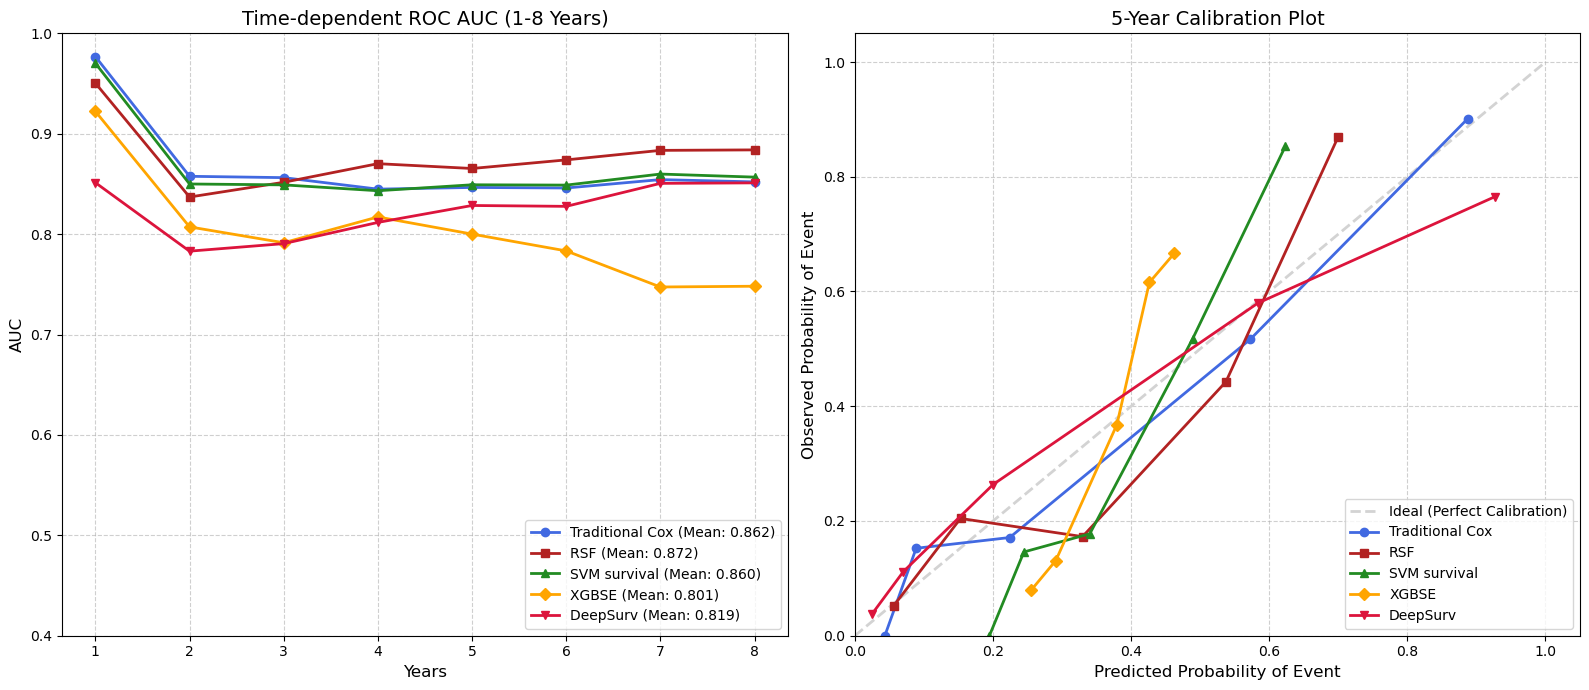

In [39]:
# ===放入比較的模型 ===
my_models = {
    "Traditional Cox": cox_model,
    "RSF": rsf_final_model,
    "SVM survival": svm_final_model,
    "XGBSE": xgbse_final_model,
    "DeepSurv": final_model  
}

# === 定義每個模型對應的顏色 ===
my_colors = {
    "Traditional Cox": "royalblue",
    "RSF": "firebrick",
    "SVM survival": "forestgreen",
    "XGBSE": "orange",
    "DeepSurv": "crimson"      
}

# === 呼叫函式繪圖與評估 ===
compare_survival_models(
    models_dict=my_models, 
    X_train=X_train, y_train=y_train_struct, 
    X_test=X_test, y_test=y_test_struct,
    colors_dict=my_colors
)

In [26]:
# ============================================================
# 直接使用剛剛已訓練完成的五個 final models
# 計算固定 Test Set 的 Harrell's C-index
# 並以 paired bootstrap 比較模型差異
# 多組兩兩比較則使用 Holm method 進行校正。
# ============================================================

import random
import warnings

import numpy as np
import pandas as pd
from tqdm import tqdm

import torch

from sksurv.metrics import concordance_index_censored
from statsmodels.stats.multitest import multipletests

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

# ============================================================
# 基本設定
# ============================================================

GLOBAL_SEED = 42
N_BOOTSTRAPS = 2000

random.seed(GLOBAL_SEED)
np.random.seed(GLOBAL_SEED)
torch.manual_seed(GLOBAL_SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(GLOBAL_SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device( "cuda" if torch.cuda.is_available() else "cpu" )

print(f"Device: {device}")

# ============================================================
# 確認既有模型與資料仍存在
# ============================================================

required_object_names = [
    "cox_model",
    "rsf_final_model",
    "svm_final_model",
    "final_model",
    "xgbse_final_model",
    "X_test",
    "y_test_struct",
]

missing_objects = [
    name for name in required_object_names
    if name not in globals()
]

if missing_objects:
    raise NameError( "找不到以下物件，請先執行前面的模型訓練程式：" + ", ".join(missing_objects) )

if X_test.isnull().any().any():
    raise ValueError("X_test 包含缺失值。")

if not np.isfinite( X_test.to_numpy(dtype=float) ).all():
    raise ValueError( "X_test 包含 NaN 或 infinite values。" )

if len(X_test) != len(y_test_struct):
    raise ValueError( "X_test 與 y_test_struct 的樣本數不一致。" )

print(f"Test set size: {len(X_test)}")
print( f"Test events: " f"{int(y_test_struct['event'].sum())}" )

# ============================================================
# 使用final models 產生 Test Set risk scores
# ============================================================

print( "\n使用已訓練完成的五個模型" "產生 Test Set risk scores..." )

# Traditional Cox
cox_pred_test = np.asarray( cox_model.predict(X_test), dtype=float ).reshape(-1)

# Random Survival Forest
rsf_pred_test = np.asarray( rsf_final_model.predict(X_test), dtype=float ).reshape(-1)

# Survival SVM
svm_pred_test = np.asarray( svm_final_model.predict(X_test), dtype=float ).reshape(-1)

# DeepSurv
final_model = final_model.to(device)
final_model.eval()

X_test_tensor = torch.tensor( X_test.to_numpy(dtype=np.float32), dtype=torch.float32, device=device )

with torch.no_grad():
    deepsurv_pred_test = ( final_model(X_test_tensor) .detach() .cpu() .numpy() .reshape(-1) )

# XGBSE
xgbse_survival_test = ( xgbse_final_model.predict(X_test) )

if not isinstance( xgbse_survival_test, pd.DataFrame ):
    xgbse_survival_test = pd.DataFrame( xgbse_survival_test )

# 延續原本的 risk score 定義：
# 最後一個預測時間點的事件風險
xgbse_pred_test = ( 1.0 - xgbse_survival_test .iloc[:, -1] .to_numpy(dtype=float) )

# ============================================================
#  Test Set predictions
# ============================================================

test_event = np.asarray( y_test_struct["event"], dtype=bool )

test_time = np.asarray( y_test_struct["time"], dtype=float )

predictions = {
    "Traditional Cox": cox_pred_test,
    "RSF": rsf_pred_test,
    "Survival SVM": svm_pred_test,
    "DeepSurv": deepsurv_pred_test,
    "XGBSE": xgbse_pred_test,
}

n_test = len(test_time)

for model_name, risk_score in predictions.items():

    risk_score = np.asarray( risk_score, dtype=float ).reshape(-1)

    if len(risk_score) != n_test:
        raise ValueError( f"{model_name} 預測數量為 " f"{len(risk_score)}，" f"但 test set 有 {n_test} 筆。" )

    if not np.isfinite(risk_score).all():
        raise ValueError( f"{model_name} 的預測包含 " "NaN 或 infinite value。" )

    predictions[model_name] = risk_score

# ============================================================
# C-index
# ============================================================

original_cindex = {}

for model_name, risk_score in predictions.items():

    original_cindex[model_name] = ( concordance_index_censored( test_event, test_time, risk_score )[0] )

print("\n" + "=" * 72)
print( "既有 final models 在固定 Test Set 的 " "Harrell's C-index" )
print("=" * 72)

for model_name, c_index in sorted( original_cindex.items(), key=lambda x: x[1], reverse=True ):
    print( f"{model_name:<20}: " f"{c_index:.4f}" )

# ============================================================
#. 固定 Test Set 的 Paired Bootstrap
# ============================================================

rng = np.random.default_rng( GLOBAL_SEED )

bootstrap_scores = {
    model_name: []
    for model_name in predictions
}

n_skipped = 0

print( f"\n開始進行固定 Test Set 的 " f"{N_BOOTSTRAPS} 次 paired bootstrap..." )

for _ in tqdm( range(N_BOOTSTRAPS), desc="Paired bootstrap" ):

    boot_idx = rng.choice( np.arange(n_test), size=n_test, replace=True )

    event_boot = test_event[boot_idx]
    time_boot = test_time[boot_idx]

    if event_boot.sum() == 0:
        n_skipped += 1
        continue

    current_scores = {}
    valid_iteration = True

    for model_name, risk_score in predictions.items():

        try:
            c_index = ( concordance_index_censored( event_boot, time_boot, risk_score[boot_idx] )[0] )

            if not np.isfinite(c_index):
                valid_iteration = False
                break

            current_scores[model_name] = c_index

        except ValueError:
            valid_iteration = False
            break

    if valid_iteration:

        for model_name, c_index in ( current_scores.items() ):
            bootstrap_scores[
                model_name
            ].append(c_index)

    else:
        n_skipped += 1

n_successful = len( next(iter(bootstrap_scores.values())) )

print("\nBootstrap 完成")
print( f"Successful bootstrap samples: " f"{n_successful}/{N_BOOTSTRAPS}" )
print( f"Skipped bootstrap samples: " f"{n_skipped}" )

if n_successful == 0:
    raise RuntimeError( "所有 bootstrap samples 均無法計算 C-index。" )

# ============================================================
# 各模型 Test C-index 與 Bootstrap 95% CI
# ============================================================

summary_rows = []

for model_name, scores in bootstrap_scores.items():

    score_array = np.asarray( scores, dtype=float )

    ci_lower, ci_upper = np.percentile( score_array, [2.5, 97.5] )

    summary_rows.append({ "Model": model_name, "Test C-index": ( original_cindex[model_name] ), "Bootstrap mean": ( score_array.mean() ), "95% CI lower": ci_lower, "95% CI upper": ci_upper, "Successful bootstraps": ( len(score_array) ), })

df_summary = ( pd.DataFrame(summary_rows) .sort_values( by="Test C-index", ascending=False ) .reset_index(drop=True) )

print("\n" + "=" * 90)
print( "各模型於固定 Test Set 的 " "Harrell's C-index 與 95% CI" )
print("=" * 90)

print( df_summary.to_string( index=False, formatters={ "Test C-index": "{:.4f}".format, "Bootstrap mean": "{:.4f}".format, "95% CI lower": "{:.4f}".format, "95% CI upper": "{:.4f}".format, } ) )

# ============================================================
#  模型間 C-index 差值的 Paired Bootstrap
# ============================================================

model_names = list(predictions.keys())

comparison_rows = []
raw_p_values = []

for i in range(len(model_names)):

    for j in range(i + 1, len(model_names)):

        model_a = model_names[i]
        model_b = model_names[j]

        scores_a = np.asarray( bootstrap_scores[model_a], dtype=float )

        scores_b = np.asarray( bootstrap_scores[model_b], dtype=float )

        bootstrap_diff = ( scores_a - scores_b )

        original_diff = ( original_cindex[model_a] - original_cindex[model_b] )

        diff_ci_lower, diff_ci_upper = ( np.percentile( bootstrap_diff, [2.5, 97.5] ) )

        b = len(bootstrap_diff)

        p_lower = ( np.sum( bootstrap_diff <= 0 ) + 1 ) / (b + 1)

        p_upper = ( np.sum( bootstrap_diff >= 0 ) + 1 ) / (b + 1)

        raw_p_value = min( 1.0, 2.0 * min( p_lower, p_upper ) )

        raw_p_values.append( raw_p_value )

        comparison_rows.append({ "Comparison": ( f"{model_a} vs {model_b}" ), "Model A": model_a, "Model B": model_b, "Delta C-index (A-B)": ( original_diff ), "95% CI lower": ( diff_ci_lower ), "95% CI upper": ( diff_ci_upper ), "Raw p-value": ( raw_p_value ), })

# ============================================================
#Holm 多重比較校正
# ============================================================

reject_null, adjusted_p_values, _, _ = ( multipletests( raw_p_values, alpha=0.05, method="holm" ) )

for row, adjusted_p, reject in zip( comparison_rows, adjusted_p_values, reject_null ):

    row[
        "Holm-adjusted p-value"
    ] = adjusted_p

    row[
        "95% CI excludes 0"
    ] = ( "Yes" if ( row["95% CI lower"] > 0 or row["95% CI upper"] < 0 ) else "No" )

    row[
        "Significant after Holm"
    ] = ( "Yes" if reject else "No" )

df_comparisons = pd.DataFrame( comparison_rows )

print("\n" + "=" * 120)
print( "五個模型 Harrell's C-index 的 " "Paired Bootstrap 兩兩比較" )
print("=" * 120)

print( df_comparisons[ [ "Comparison", "Delta C-index (A-B)", "95% CI lower", "95% CI upper", "Raw p-value", "Holm-adjusted p-value", "95% CI excludes 0", "Significant after Holm", ] ].to_string( index=False, formatters={ "Delta C-index (A-B)": ( "{:.4f}".format ), "95% CI lower": ( "{:.4f}".format ), "95% CI upper": ( "{:.4f}".format ), "Raw p-value": ( "{:.4f}".format ), "Holm-adjusted p-value": ( "{:.4f}".format ), } ) )

Device: cpu
Test set size: 126
Test events: 45

使用已訓練完成的五個模型產生 Test Set risk scores...

既有 final models 在固定 Test Set 的 Harrell's C-index
RSF                 : 0.8277
Traditional Cox     : 0.8256
Survival SVM        : 0.8246
DeepSurv            : 0.7847
XGBSE               : 0.7669

開始進行固定 Test Set 的 2000 次 paired bootstrap...


Paired bootstrap: 100%|████████████████████| 2000/2000 [00:04<00:00, 479.13it/s]



Bootstrap 完成
Successful bootstrap samples: 2000/2000
Skipped bootstrap samples: 0

各模型於固定 Test Set 的 Harrell's C-index 與 95% CI
          Model Test C-index Bootstrap mean 95% CI lower 95% CI upper  Successful bootstraps
            RSF       0.8277         0.8280       0.7701       0.8825                   2000
Traditional Cox       0.8256         0.8253       0.7615       0.8808                   2000
   Survival SVM       0.8246         0.8244       0.7625       0.8794                   2000
       DeepSurv       0.7847         0.7846       0.7171       0.8492                   2000
          XGBSE       0.7669         0.7670       0.6994       0.8326                   2000

五個模型 Harrell's C-index 的 Paired Bootstrap 兩兩比較
                     Comparison Delta C-index (A-B) 95% CI lower 95% CI upper Raw p-value Holm-adjusted p-value 95% CI excludes 0 Significant after Holm
         Traditional Cox vs RSF             -0.0021      -0.0328       0.0252      0.8756                1.0000 

# 可解釋分析

     Feature Coefficient Hazard Ratio Absolute Coefficient   Direction
     Stage_2      1.2442       3.4702               1.2442 Higher risk
   Ascites_1      1.0231       2.7819               1.0231 Higher risk
        ECOG      0.6884       1.9905               0.6884 Higher risk
Resec_status      0.6664       1.9471               0.6664 Higher risk
      Cell_2      0.6451       1.9062               0.6451 Higher risk
       Grade      0.2636       1.3016               0.2636 Higher risk
      Alb_11     -0.0372       0.9635               0.0372  Lower risk
       NLR_1      0.0227       1.0230               0.0227 Higher risk
       BMI_1     -0.0221       0.9781               0.0221  Lower risk
       SMI_1      0.0151       1.0152               0.0151 Higher risk
         Age     -0.0016       0.9984               0.0016  Lower risk
       PLR_1     -0.0006       0.9994               0.0006  Lower risk


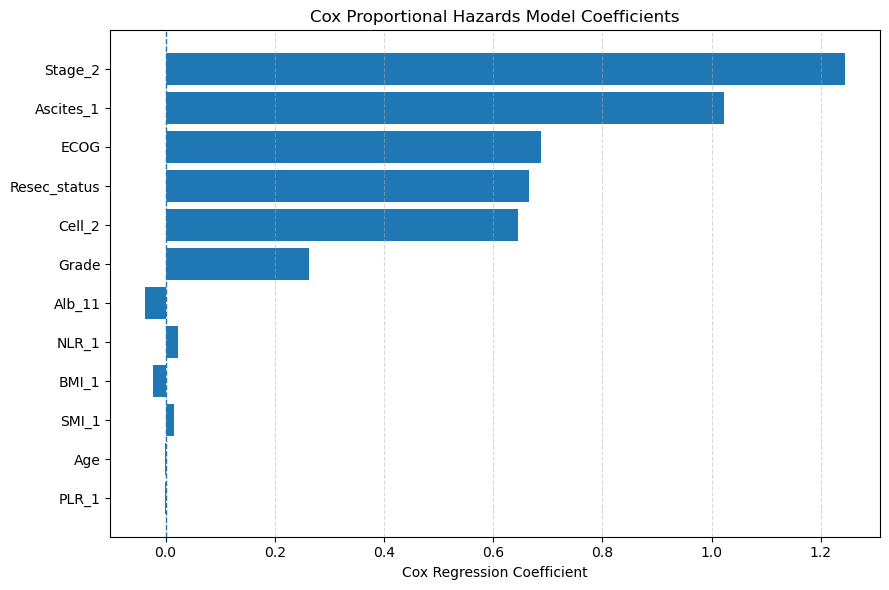

In [27]:
# ============================================================
# Cox 模型可解釋分析：係數排序與視覺化
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# 取出特徵名稱與 Cox regression coefficients
feature_names = X_train.columns
coef = np.asarray(
    cox_model.coef_,
    dtype=float
).reshape(-1)


# 組成結果表格
df_cox_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coef
})

# Hazard ratio
df_cox_importance["Hazard Ratio"] = np.exp(
    df_cox_importance["Coefficient"]
)

# 係數絕對值僅用於排序
df_cox_importance["Absolute Coefficient"] = (
    df_cox_importance["Coefficient"].abs()
)

# 判斷風險方向
df_cox_importance["Direction"] = np.where(
    df_cox_importance["Coefficient"] > 0,
    "Higher risk",
    "Lower risk"
)

# 依係數絕對值排序
df_cox_importance = (
    df_cox_importance
    .sort_values(
        by="Absolute Coefficient",
        ascending=False
    )
    .reset_index(drop=True)
)


# 顯示結果
print(
    df_cox_importance.head(20).to_string(
        index=False,
        formatters={
            "Coefficient": "{:.4f}".format,
            "Hazard Ratio": "{:.4f}".format,
            "Absolute Coefficient": "{:.4f}".format
        }
    )
)


# ============================================================
# Cox coefficients
# ============================================================

top_n = min(
    15,
    len(df_cox_importance)
)

top_features = (
    df_cox_importance
    .head(top_n)
    .iloc[::-1]
)

plt.figure(figsize=(9, 6))

plt.barh(
    top_features["Feature"],
    top_features["Coefficient"]
)

# coefficient = 0 代表無方向性影響
plt.axvline(
    x=0,
    linestyle="--",
    linewidth=1
)

plt.xlabel("Cox Regression Coefficient")
plt.ylabel("")
plt.title("Cox Proportional Hazards Model Coefficients")

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.5
)

plt.tight_layout()
plt.show()

開始計算 RSF Training Set SHAP values：
Background samples = 100
Explained samples = 501
Features = 12
max_evals = 250


PermutationExplainer explainer: 502it [36:31,  4.39s/it]                        


RSF Training Set SHAP values 計算完成。

開始計算 RSF Test Set SHAP values：
Background samples = 100
Explained samples = 126
Features = 12
max_evals = 250


PermutationExplainer explainer: 127it [08:48,  4.30s/it]                        

RSF Test Set SHAP values 計算完成。


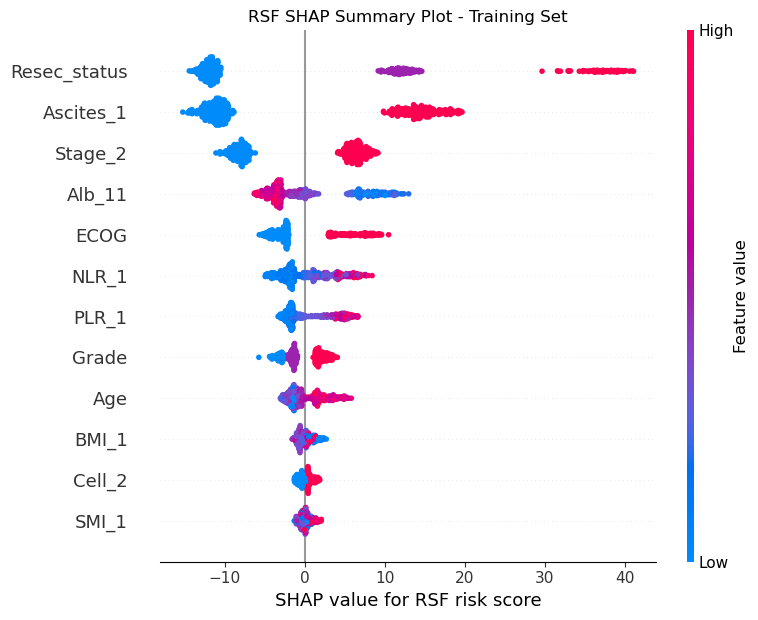

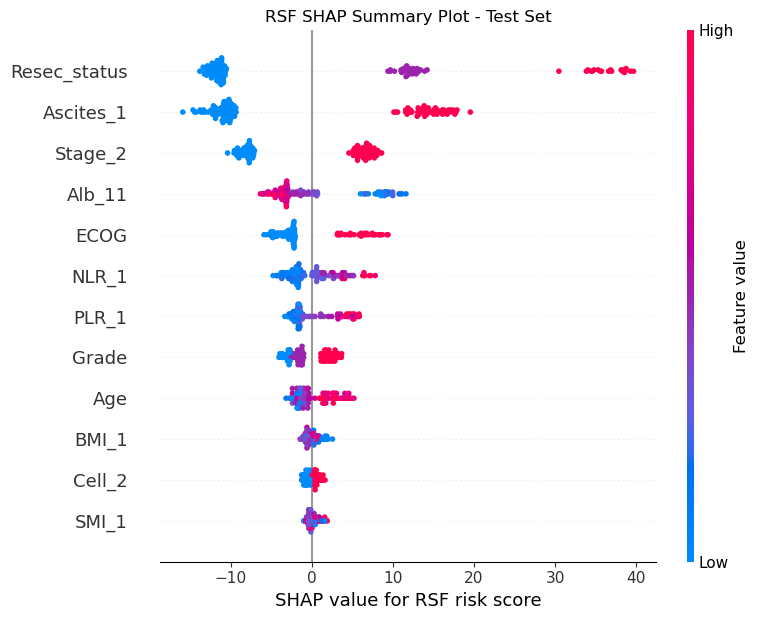

In [34]:
# ============================================================
# RSF 可解釋分析：Permutation SHAP + Beeswarm Summary Plot
#
# Background data：training set 抽樣
# Explained data：training set 與固定 test set
# Model output：RSF risk score
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap


# ============================================================
# 確認資料格式與欄位順序
# ============================================================

feature_names = X_train.columns.tolist()

if list(X_train.columns) != list(X_test.columns):
    raise ValueError(
        "X_train 與 X_test 的欄位名稱或順序不同。"
    )

if X_train.isnull().any().any():
    raise ValueError("X_train 包含缺失值。")

if X_test.isnull().any().any():
    raise ValueError("X_test 包含缺失值。")


#  RSF prediction function
def rsf_predict_risk(x):
    """
    輸出 RSF 整體 risk score。

    分數越高，代表模型預測的死亡風險越高，
    預期存活時間越短。
    """

    if isinstance(x, pd.DataFrame):
        x_df = x.copy()
        x_df = x_df[feature_names]

    else:
        x_df = pd.DataFrame(
            x,
            columns=feature_names
        )

    risk_score = rsf_final_model.predict(x_df)

    return np.asarray(
        risk_score,
        dtype=float
    ).reshape(-1)


# ============================================================
# 建立 background data
#
# Background 僅從 training set 抽取，避免使用 test outcome 或讓 test set 參與模型基準建立。
# ============================================================

BACKGROUND_SIZE = min(
    100,
    len(X_train)
)

X_background = X_train.sample(
    n=BACKGROUND_SIZE,
    random_state=42
).copy()


# ============================================================
# 選擇 training 與 test samples
# ============================================================

X_explain_train = X_train.copy()
X_explain_test = X_test.copy()

# ============================================================
# Permutation SHAP explainer
# ============================================================

explainer = shap.Explainer(
    model=rsf_predict_risk,
    masker=X_background,
    algorithm="permutation",
    feature_names=feature_names,
    seed=42
)


# ============================================================
# 算 SHAP values
# ============================================================

n_features = X_train.shape[1]

MAX_EVALS = 10 * (
    2 * n_features + 1
)

print(
    f"開始計算 RSF Training Set SHAP values：\n"
    f"Background samples = {len(X_background)}\n"
    f"Explained samples = {len(X_explain_train)}\n"
    f"Features = {n_features}\n"
    f"max_evals = {MAX_EVALS}"
)

shap_values_rsf_train = explainer(
    X_explain_train,
    max_evals=MAX_EVALS,
    batch_size="auto"
)

print("RSF Training Set SHAP values 計算完成。\n")

print(
    f"開始計算 RSF Test Set SHAP values：\n"
    f"Background samples = {len(X_background)}\n"
    f"Explained samples = {len(X_explain_test)}\n"
    f"Features = {n_features}\n"
    f"max_evals = {MAX_EVALS}"
)

shap_values_rsf_test = explainer(
    X_explain_test,
    max_evals=MAX_EVALS,
    batch_size="auto"
)

print("RSF Test Set SHAP values 計算完成。")


# ============================================================
# 繪製 Training Set SHAP Beeswarm Summary Plot
# ============================================================

plt.figure(figsize=(9, 7))

shap.plots.beeswarm(
    shap_values_rsf_train,
    max_display=min(15, n_features),
    show=False
)

plt.xlabel(
    "SHAP value for RSF risk score"
)

plt.title(
    "RSF SHAP Summary Plot - Training Set"
)

plt.tight_layout()
plt.show()


# ============================================================
# 繪製 Test Set SHAP Beeswarm Summary Plot
# ============================================================

plt.figure(figsize=(9, 7))

shap.plots.beeswarm(
    shap_values_rsf_test,
    max_display=min(15, n_features),
    show=False
)

plt.xlabel(
    "SHAP value for RSF risk score"
)

plt.title(
    "RSF SHAP Summary Plot - Test Set"
)

plt.tight_layout()
plt.show()

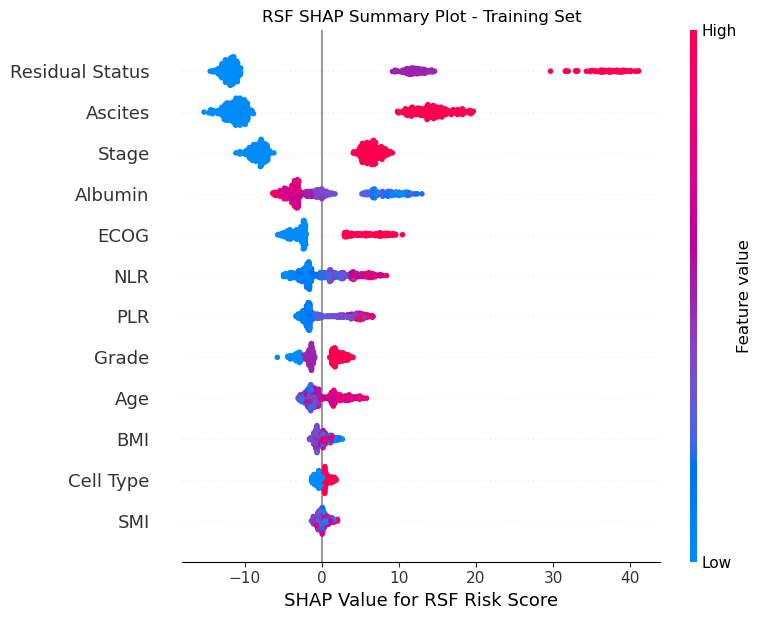

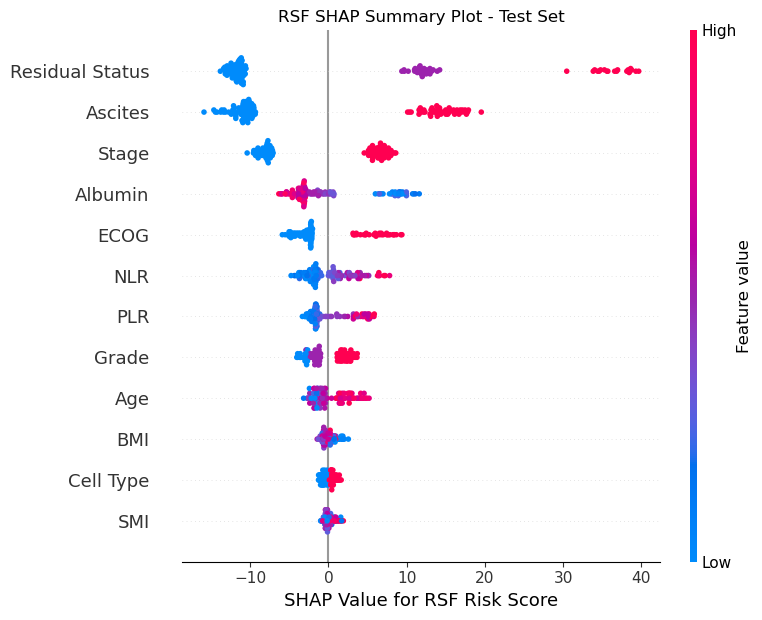

In [40]:
# 重新設定 Training Set 與 Test Set 的顯示名稱
feature_name_map = {
    "Resec_status": "Residual Status",
    "Ascites_1": "Ascites",
    "Stage_2": "Stage",
    "ECOG": "ECOG",
    "Alb_11": "Albumin",
    "NLR_1": "NLR",
    "Grade": "Grade",
    "PLR_1": "PLR",
    "Age": "Age",
    "Cell_2": "Cell Type",
    "BMI_1": "BMI",
    "SMI_1": "SMI"
}

display_feature_names_train = [
    feature_name_map.get(name, name)
    for name in X_explain_train.columns
]

display_feature_names_test = [
    feature_name_map.get(name, name)
    for name in X_explain_test.columns
]

shap_values_rsf_train.feature_names = display_feature_names_train
shap_values_rsf_test.feature_names = display_feature_names_test


# ============================================================
# Training Set Beeswarm Plot
# ============================================================

plt.figure(figsize=(10, 7))

shap.plots.beeswarm(
    shap_values_rsf_train,
    max_display=min(15, X_explain_train.shape[1]),
    show=False
)

plt.xlabel("SHAP Value for RSF Risk Score")
plt.title("RSF SHAP Summary Plot - Training Set")

plt.tight_layout()
plt.show()


# ============================================================
# Test Set Beeswarm Plot
# ============================================================

plt.figure(figsize=(10, 7))

shap.plots.beeswarm(
    shap_values_rsf_test,
    max_display=min(15, X_explain_test.shape[1]),
    show=False
)

plt.xlabel("SHAP Value for RSF Risk Score")
plt.title("RSF SHAP Summary Plot - Test Set")

plt.tight_layout()
plt.show()

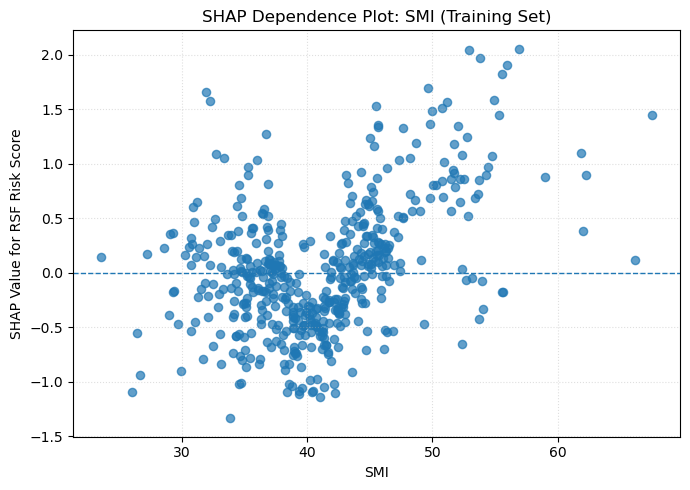

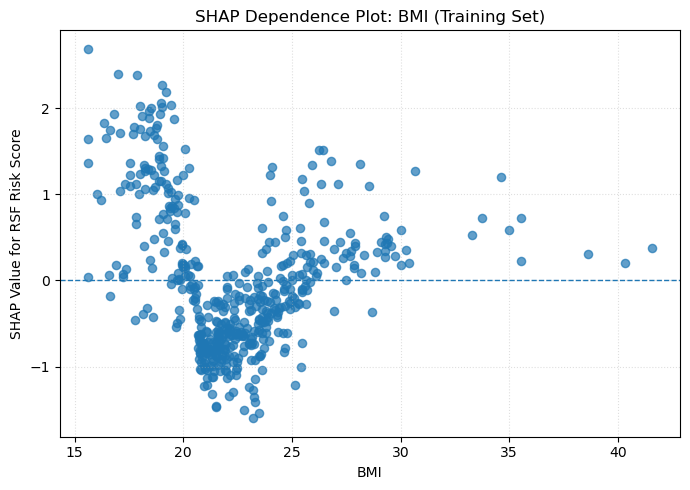

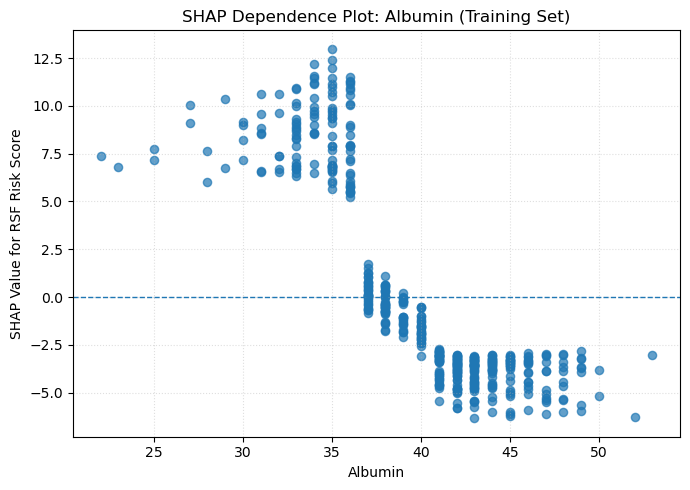

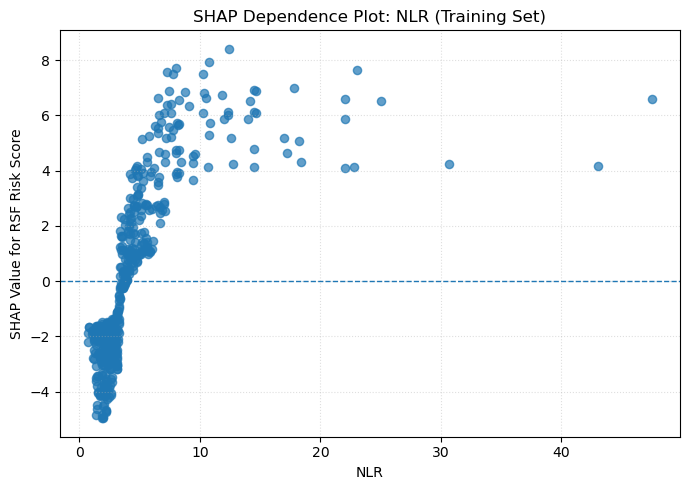

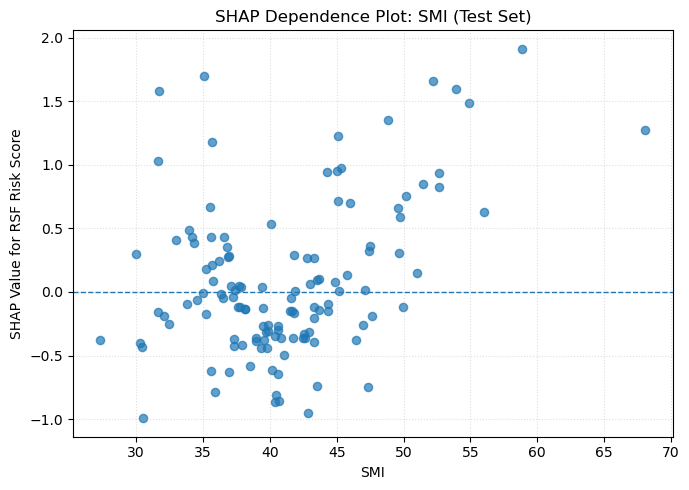

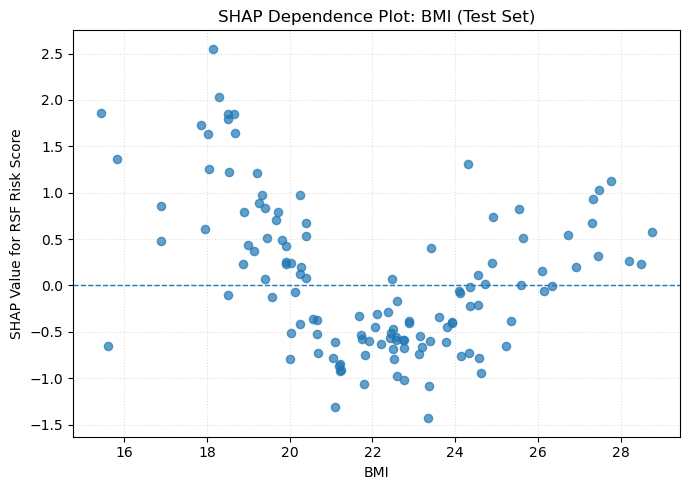

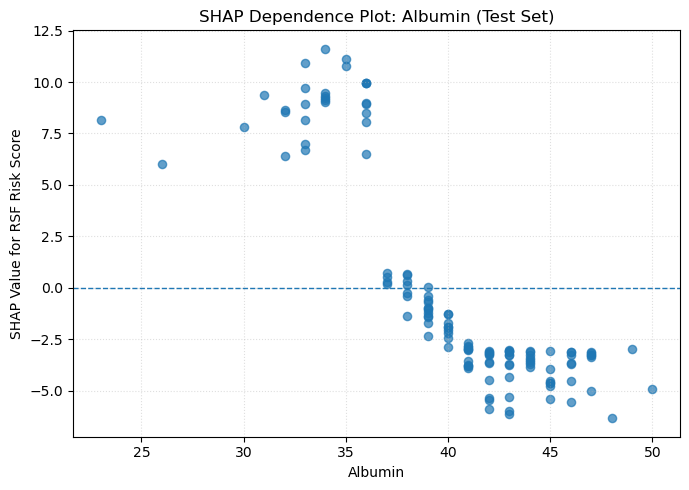

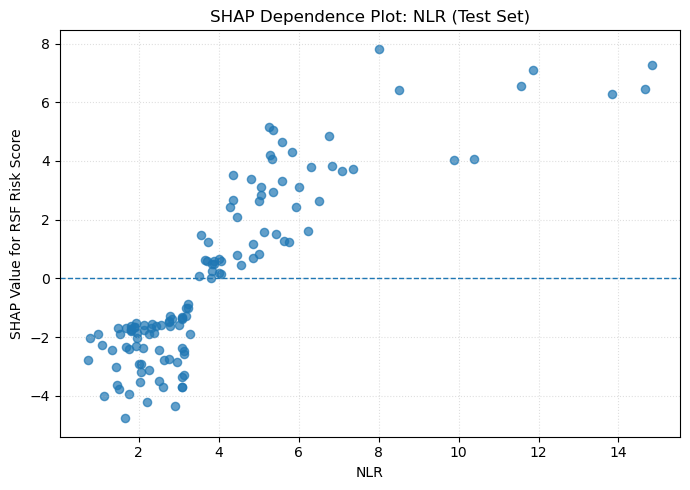

In [36]:
# ============================================================
# RSF SHAP Dependence Plots
#
# x 軸：特徵值
# y 軸：SHAP value for RSF risk score
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# 指定變數
continuous_features = [
    "SMI_1",
    "BMI_1",
    "Alb_11",
    "NLR_1"
]

categorical_features = [
    "Resec_status",
    "Ascites_1",
    "Stage_2",
    "ECOG"
]


# 顯示名稱
feature_display_names = {
    "SMI_1": "SMI",
    "BMI_1": "BMI",
    "Alb_11": "Albumin",
    "NLR_1": "NLR",
    "Resec_status": "Residual Status",
    "Ascites_1": "Ascites",
    "Stage_2": "Stage",
    "ECOG": "ECOG"
}


# 使用前面Training Set 與 Test Set SHAP values
X_explain_train = X_train.copy()
X_explain_test = X_test.copy()

required_objects = [
    "shap_values_rsf_train",
    "shap_values_rsf_test"
]

missing_objects = [
    name for name in required_objects
    if name not in globals()
]

if missing_objects:
    raise NameError(
        "找不到以下物件，請先執行前面的 SHAP 計算程式："
        + ", ".join(missing_objects)
    )


# 圖函數

def plot_continuous_shap_dependence(
    X_explain,
    shap_values,
    dataset_name
):

    if shap_values.values.shape[0] != len(X_explain):
        raise ValueError(
            f"{dataset_name} 的 SHAP values 與 X_explain 樣本數不同。"
        )

    if shap_values.values.shape[1] != X_explain.shape[1]:
        raise ValueError(
            f"{dataset_name} 的 SHAP values 與 X_explain 特徵數不同。"
        )

    original_feature_names = X_explain.columns.tolist()

    missing_features = [
        feature
        for feature in continuous_features + categorical_features
        if feature not in original_feature_names
    ]

    if missing_features:
        raise ValueError(
            f"{dataset_name} 中不存在以下特徵："
            + ", ".join(missing_features)
        )


    # 畫連續變數 SHAP dependence plot
    for feature in continuous_features:

        feature_idx = original_feature_names.index(feature)

        x_values = X_explain[feature].to_numpy(dtype=float)
        shap_feature_values = shap_values.values[:, feature_idx]

        valid_mask = (
            np.isfinite(x_values)
            & np.isfinite(shap_feature_values)
        )

        x_plot = x_values[valid_mask]
        shap_plot = shap_feature_values[valid_mask]

        plt.figure(figsize=(7, 5))

        plt.scatter(
            x_plot,
            shap_plot,
            alpha=0.7,
            s=35
        )

        # SHAP = 0 參考線
        plt.axhline(
            y=0,
            linestyle="--",
            linewidth=1
        )

        plt.xlabel(
            feature_display_names[feature]
        )

        plt.ylabel(
            "SHAP Value for RSF Risk Score"
        )

        plt.title(
            f"SHAP Dependence Plot: "
            f"{feature_display_names[feature]} "
            f"({dataset_name})"
        )

        plt.grid(
            linestyle=":",
            alpha=0.4
        )

        plt.tight_layout()
        plt.show()


# 分別畫 Training Set 與 Test Set

plot_continuous_shap_dependence(
    X_explain=X_explain_train,
    shap_values=shap_values_rsf_train,
    dataset_name="Training Set"
)

plot_continuous_shap_dependence(
    X_explain=X_explain_test,
    shap_values=shap_values_rsf_test,
    dataset_name="Test Set"
)

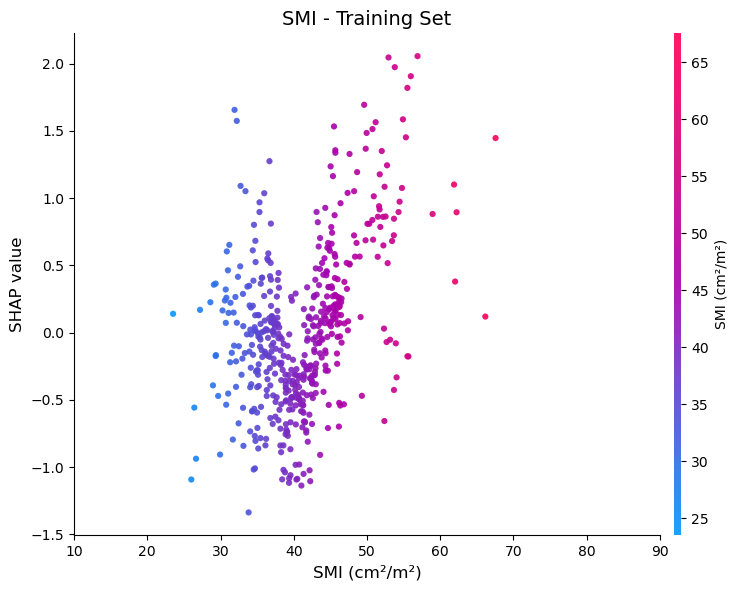

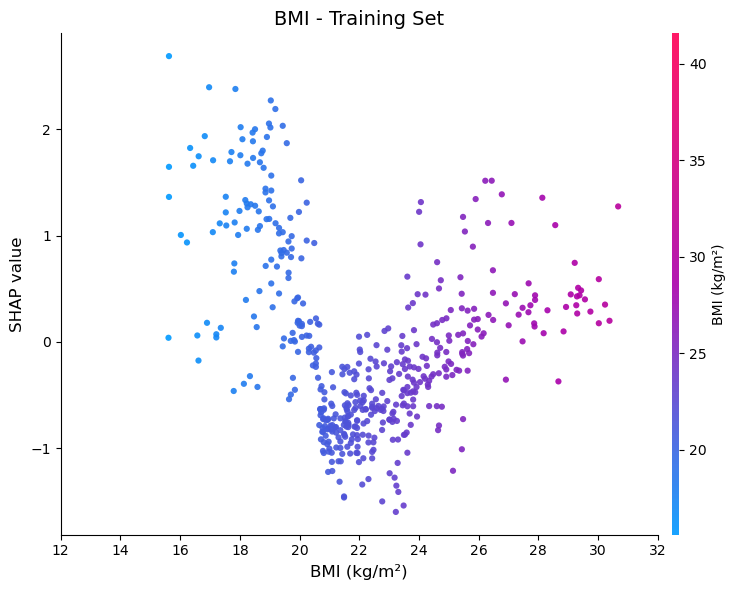

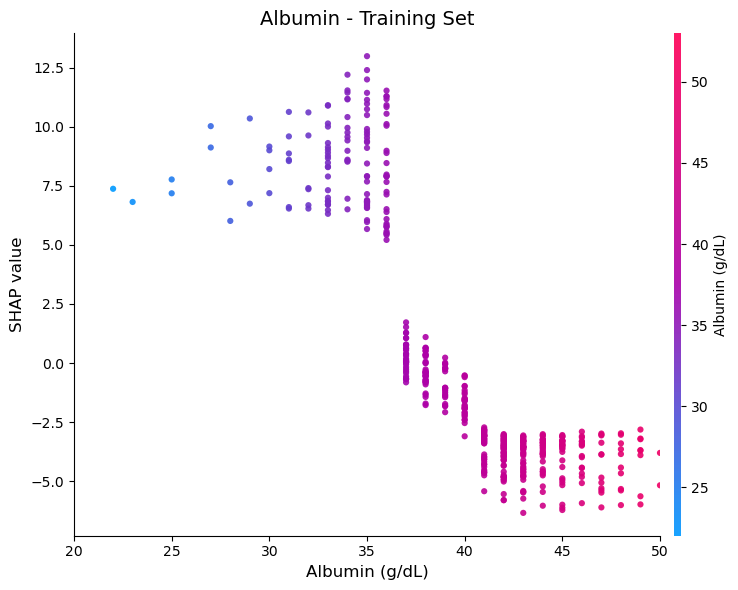

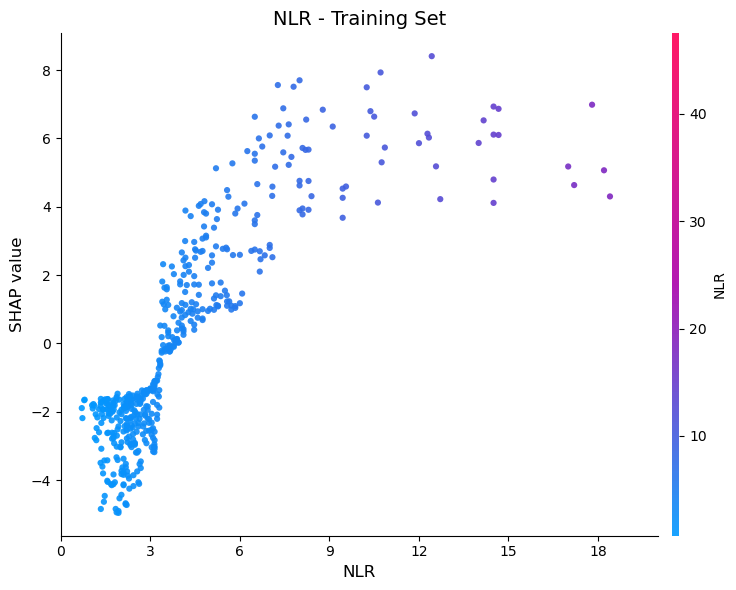

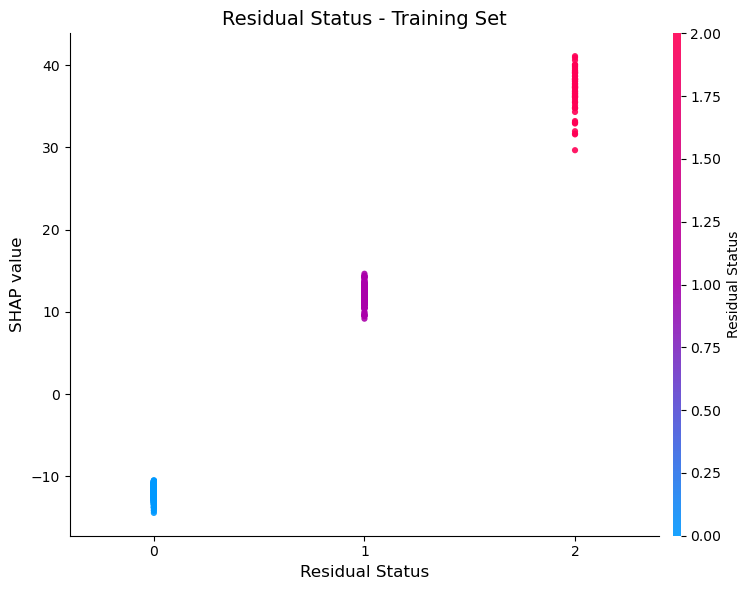

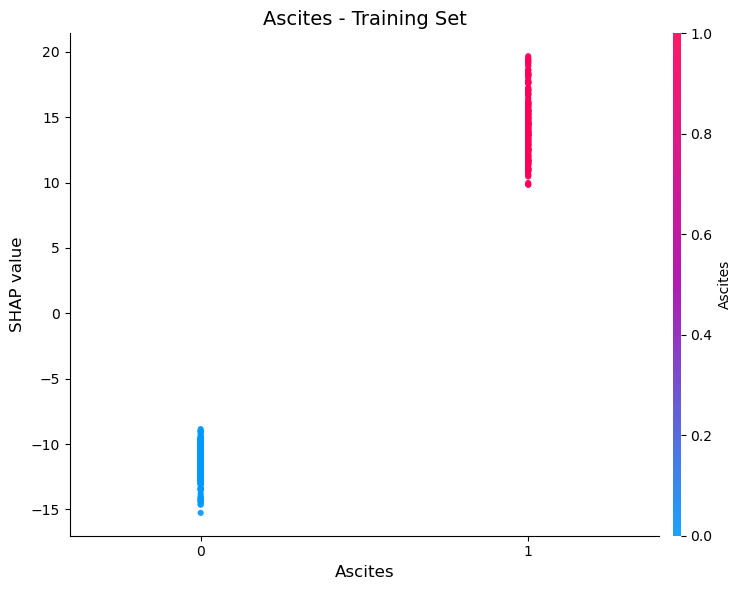

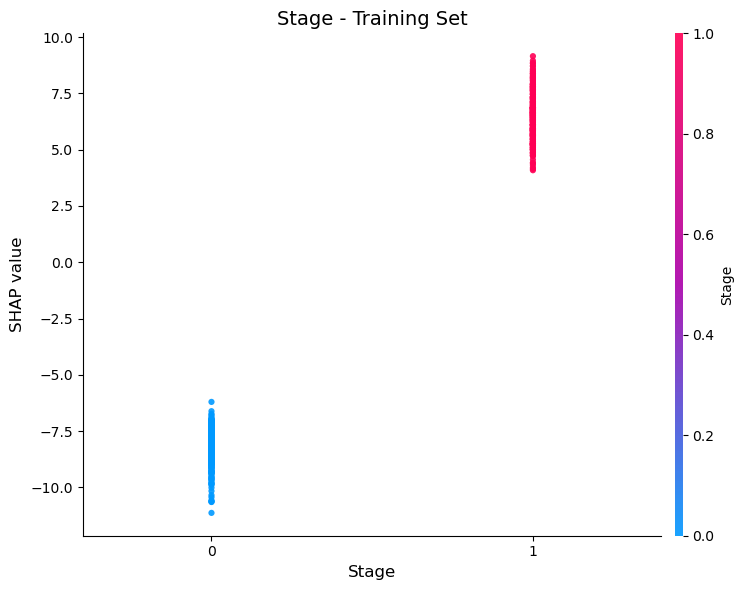

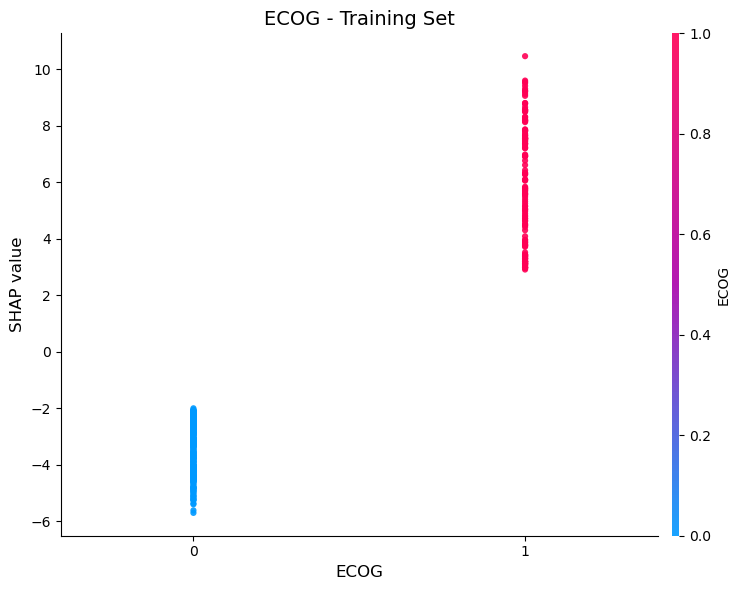

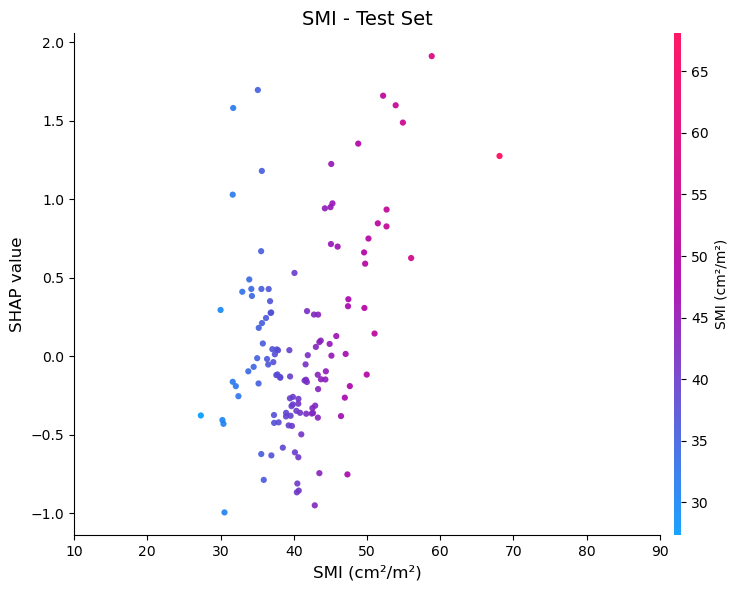

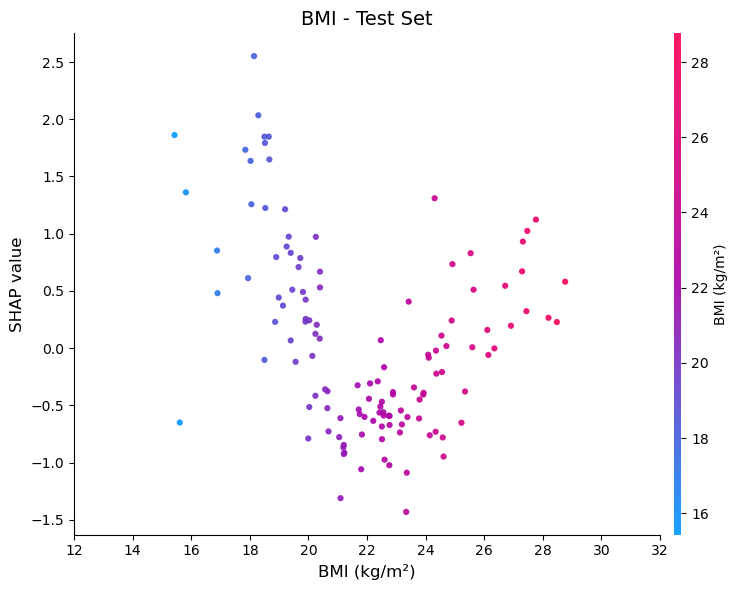

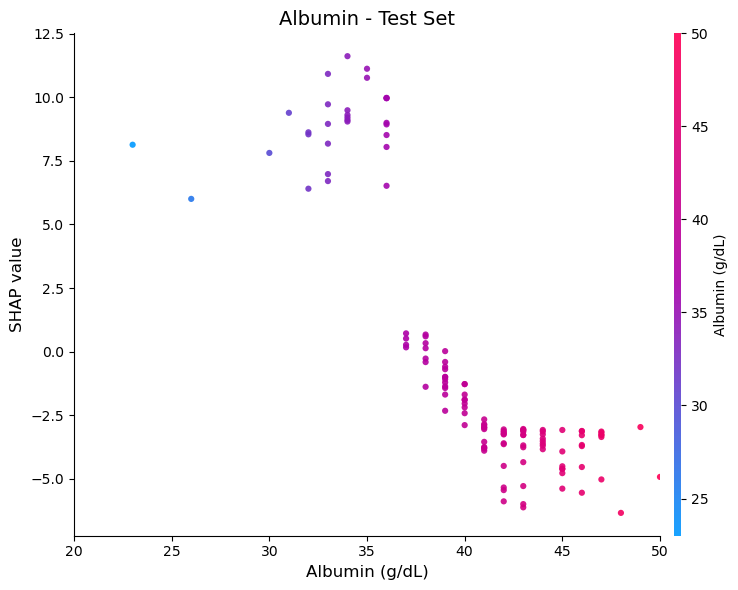

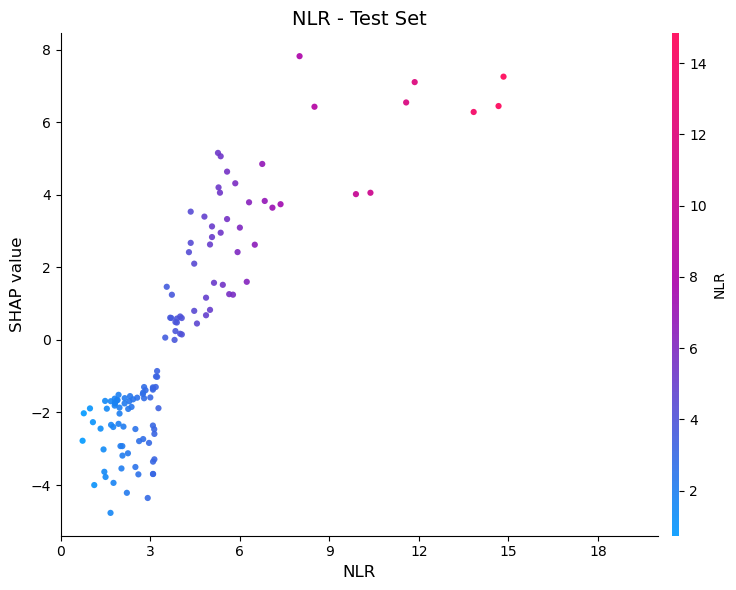

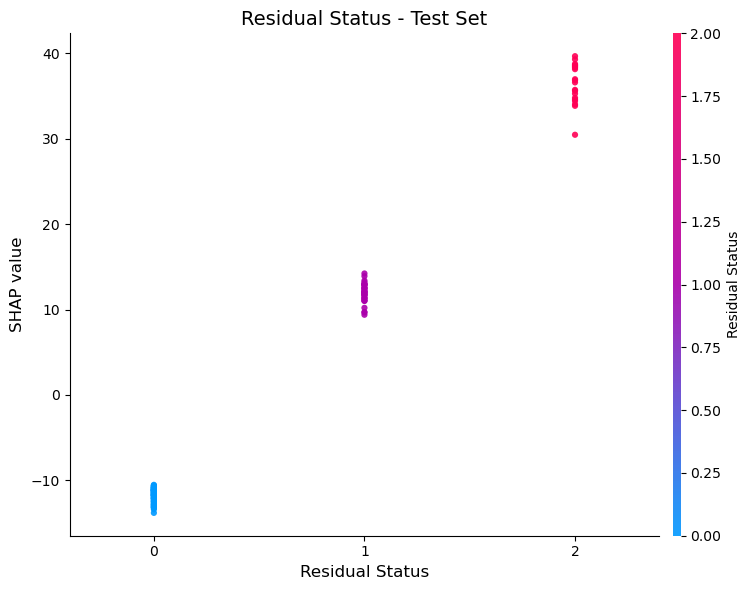

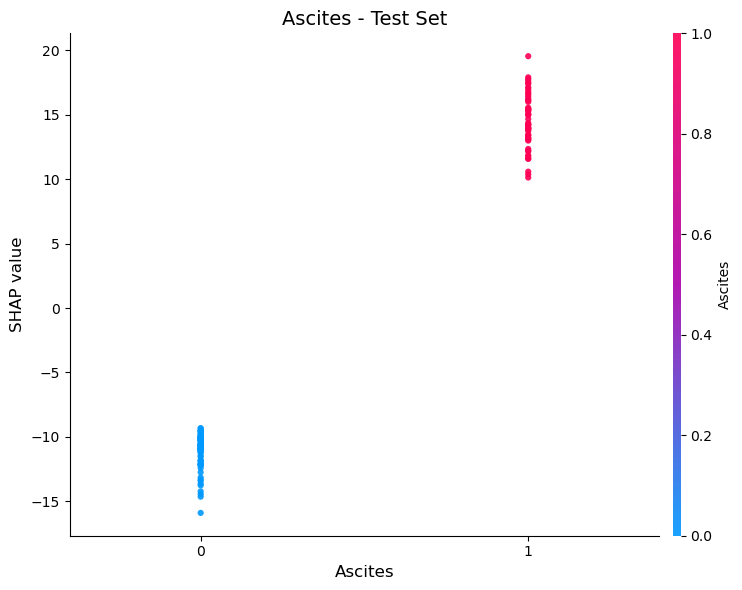

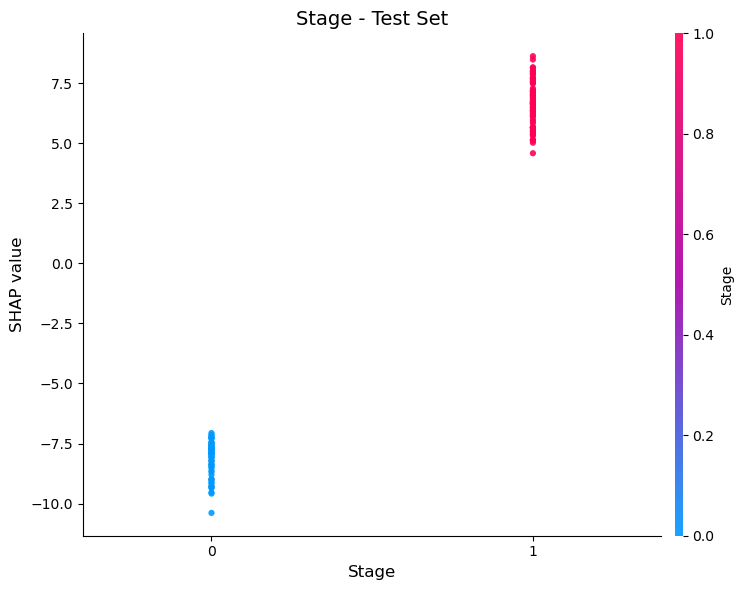

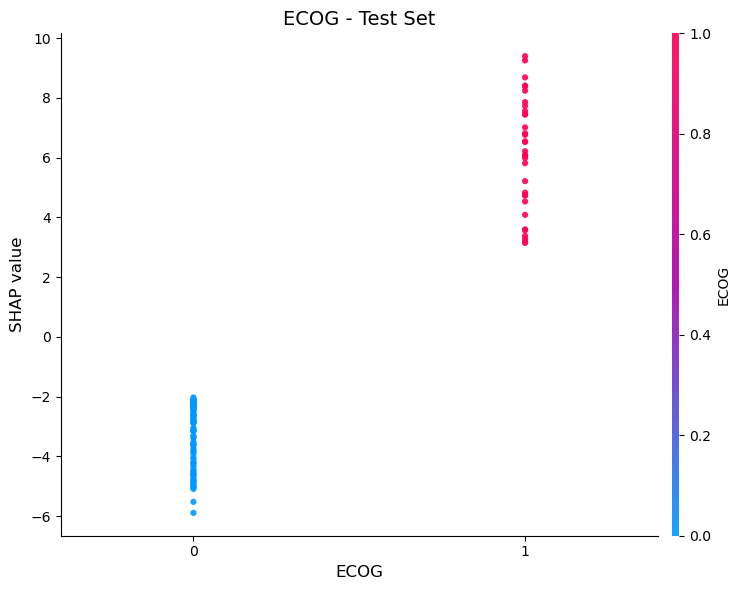

In [41]:
# ============================================================
# RSF SHAP dependence plots
# 整理呈現方式
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap


# ============================================================
#  指定特徵
# ============================================================

features_to_plot = [
    "SMI_1",
    "BMI_1",
    "Alb_11",
    "NLR_1",
    "Resec_status",
    "Ascites_1",
    "Stage_2",
    "ECOG"
]

continuous_features = {
    "SMI_1",
    "BMI_1",
    "Alb_11",
    "NLR_1"
}

categorical_features = {
    "Resec_status",
    "Ascites_1",
    "Stage_2",
    "ECOG"
}


# ============================================================
# 顯示名稱與單位
# ============================================================

feature_display_names = {
    "SMI_1": "SMI",
    "BMI_1": "BMI",
    "Alb_11": "Albumin",
    "NLR_1": "NLR",
    "Resec_status": "Residual Status",
    "Ascites_1": "Ascites",
    "Stage_2": "Stage",
    "ECOG": "ECOG"
}


feature_units = {
    "SMI_1": "cm²/m²",
    "BMI_1": "kg/m²",
    "Alb_11": "g/dL",
    "NLR_1": "",
    "Resec_status": "",
    "Ascites_1": "",
    "Stage_2": "",
    "ECOG": ""
}

# ============================================================
# 定義類別標籤
# ============================================================

category_label_map = {
    "Resec_status": {
        0: "0",
        1: "1",
        2: "2"
    },
    "Ascites_1": {
        0: "0",
        1: "1"
    },
    "Stage_2": {
        0: "0",
        1: "1"
    },
    "ECOG": {
        0: "0",
        1: "1",
        2: "2",
        3: "3"
    }
}


# ============================================================
# 自訂 x 軸範圍與刻度
# ============================================================

x_axis_settings = {
    "SMI_1": {
        "xlim": (10, 90),
        "xticks": np.arange(10, 91, 10)
    },
    "BMI_1": {
        "xlim": (12, 32),
        "xticks": np.arange(12, 33, 2)
    },
    "Alb_11": {
        "xlim": (20, 50),
        "xticks": np.arange(20, 51, 5)
    },
    "NLR_1": {
        "xlim": (0, 20),
        "xticks": np.arange(0, 21, 3)
    }
}


# ============================================================
# 確認前面已計算完成的物件存在
# ============================================================

required_objects = [
    "X_explain_train",
    "X_explain_test",
    "shap_values_rsf_train",
    "shap_values_rsf_test"
]

missing_objects = [
    name for name in required_objects
    if name not in globals()
]

if missing_objects:
    raise NameError(
        "找不到以下物件，請先執行前面的 SHAP 計算程式："
        + ", ".join(missing_objects)
    )


# ============================================================
# 自訂 colormap：藍 → 紫 → 紅
# ============================================================

cmap_custom = LinearSegmentedColormap.from_list(
    "BluePurpleRed",
    ["#0099FF", "#AA00AA", "#FF0055"]
)


# ============================================================
# 畫圖函數
# ============================================================

def plot_rsf_shap_dependence(
    feature,
    x_data,
    shap_explanation,
    dataset_name
):
    if shap_explanation.values.shape[0] != len(x_data):
        raise ValueError(
            f"{dataset_name} 的 SHAP values 與資料樣本數不一致。"
        )

    if shap_explanation.values.shape[1] != x_data.shape[1]:
        raise ValueError(
            f"{dataset_name} 的 SHAP values 與資料特徵數不一致。"
        )

    original_feature_names = x_data.columns.tolist()

    if feature not in original_feature_names:
        raise ValueError(
            f"{feature} 不存在於 {dataset_name} 資料中。"
        )

    feature_idx = original_feature_names.index(feature)

    x_values = pd.to_numeric(
        x_data[feature],
        errors="coerce"
    ).to_numpy(dtype=float)

    shap_values = np.asarray(
        shap_explanation.values[:, feature_idx],
        dtype=float
    )

    valid_mask = (
        np.isfinite(x_values)
        & np.isfinite(shap_values)
    )

    x_plot = x_values[valid_mask]
    shap_plot = shap_values[valid_mask]

    display_name = feature_display_names[feature]
    unit = feature_units.get(feature, "")

    axis_label = (
        f"{display_name} ({unit})"
        if unit
        else display_name
    )

    fig, ax = plt.subplots(figsize=(8, 6))

    scatter = ax.scatter(
        x_plot,
        shap_plot,
        c=x_plot,
        cmap=cmap_custom,
        s=20,
        alpha=0.9,
        edgecolors="none"
    )

    cbar = plt.colorbar(
        scatter,
        ax=ax,
        aspect=70,
        pad=0.02,
        shrink=1.0
    )

    cbar.set_label(axis_label, fontsize=10)
    cbar.outline.set_visible(False)

    ax.set_title(
        f"{display_name} - {dataset_name}",
        fontsize=14
    )

    ax.set_xlabel(axis_label, fontsize=12)
    ax.set_ylabel("SHAP value", fontsize=12)

    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)

    if feature in categorical_features:
        unique_values = np.sort(np.unique(x_plot))

        labels = [
            category_label_map
            .get(feature, {})
            .get(
                int(value) if float(value).is_integer() else value,
                str(value)
            )
            for value in unique_values
        ]

        ax.set_xticks(unique_values)
        ax.set_xticklabels(labels)

        if len(unique_values) > 1:
            ax.set_xlim(
                unique_values.min() - 0.4,
                unique_values.max() + 0.4
            )

    elif feature in x_axis_settings:
        setting = x_axis_settings[feature]

        if "xlim" in setting:
            ax.set_xlim(setting["xlim"])

        if "xticks" in setting:
            ax.set_xticks(setting["xticks"])

    ax.grid(False)
    plt.tight_layout()
    plt.show()


# ============================================================
# 分別畫 Training Set 與 Test Set
# ============================================================

for feature in features_to_plot:
    plot_rsf_shap_dependence(
        feature=feature,
        x_data=X_explain_train,
        shap_explanation=shap_values_rsf_train,
        dataset_name="Training Set"
    )

for feature in features_to_plot:
    plot_rsf_shap_dependence(
        feature=feature,
        x_data=X_explain_test,
        shap_explanation=shap_values_rsf_test,
        dataset_name="Test Set"
    )